# FastQC QC bundle analysis (raw vs trimmed) — mouse

Goal: run the same FastQC summary workflow on both the **raw** reads and the **FASTX-trimmed** reads, then compare results side-by-side (raw vs trimmed) at each step.

Inputs (local on this Mac):
- raw FastQC bundle: `Semester5/BIOL550/group_project/mouse/qc_bundle_raw/`
- trimmed FastQC bundle: `Semester5/BIOL550/group_project/mouse/qc_bundle_trimmed/`

Outputs (plots/tables):
- `Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/`

This notebook is designed to be **offline-friendly** (no web calls required) once the FastQC bundles are copied locally.


# FastQC QC bundle analysis (mouse)

This notebook analyzes FastQC outputs for the mouse bulk RNA-seq dataset:
- BioProject: `PRJNA1017789`
- GEO Series: `GSE243308`
- Organism: *Mus musculus* (TaxID 10090)

We compare the same SRR runs **before trimming** vs **after trimming**.

Expectation when complete:
- 26 SRRs × 2 mates = **52 FastQC ZIPs** for `raw`
- 26 SRRs × 2 mates = **52 FastQC ZIPs** for `trimmed`

If trimming is still running, the notebook will automatically compare only the SRRs present in both stages (intersection), and will list any missing SRRs.


## Dataset identifiers (mouse project)

- BioProject: `PRJNA1017789`
- GEO Series: `GSE243308`
- Runs: `SRR30333743`–`SRR30333768` (26 SRRs, paired-end)

Working assumption: this is **bulk RNA-seq** (one FASTQ pair per sample/replicate). If we later discover any single-cell runs were mixed in, we should re-scope analysis accordingly.


## Tools used (what / why / example)

Below are the **exact tools/paths** used on the Sequoia server in our pipeline, plus what the main flags mean.

### 1) SRA Toolkit (`prefetch`, `fasterq-dump`, fallback `fastq-dump`)
- **Server install (preferred):** `/usr/local/bin/sra_3.0.0/`
  - `prefetch`: `/usr/local/bin/sra_3.0.0/prefetch`
  - `fasterq-dump`: `/usr/local/bin/sra_3.0.0/fasterq-dump`
  - Fallback: `/usr/local/bin/sra_3.0.0/fastq-dump` (or `fastq-dump-orig.3.0.0` if present)
- **What it does:** downloads SRR runs from NCBI SRA and converts them to FASTQ.
- **Why we use it:** reproducible, standard way to obtain FASTQs from a public BioProject.
- **Flags used (meaning):**
  - `prefetch --transport http -O <DIR> <SRR>`: download the SRR into `<DIR>` using HTTP transport.
  - `fasterq-dump --split-files`: write paired-end reads as two files (`*_1.fastq`, `*_2.fastq`).
  - `fasterq-dump --threads <N>`: number of threads for FASTQ conversion (speed).
  - `fasterq-dump --outdir <DIR>`: where FASTQ outputs are written.
  - `fasterq-dump --temp <DIR>`: scratch directory (helps performance / avoids filling default temp).
  - `fastq-dump --split-files`: split mates into `_1`/`_2` outputs.
  - `fastq-dump --gzip`: gzip-compress outputs (writes `*.fastq.gz`).
  - `fastq-dump --origfmt`: keep original read names/format when possible.
  - `fastq-dump -O <DIR>`: output directory.

### 2) FastQC
- **Server install:** `/usr/local/bin/FASTQC_11.9/fastqc`
- **What it does:** generates per-file QC reports (PASS/WARN/FAIL modules + plots).
- **Why we use it:** quick first look for adapters, low-quality tails, GC shifts, duplication, and overrepresented sequences.
- **Flags used (meaning):**
  - `-t <N>`: number of threads.
  - `-o <DIR>`: output directory for HTML/ZIP.
  - `--noextract`: keep the `.zip` compressed (don’t auto-unzip to a folder).

### 3) FASTX-Toolkit (`fastq_quality_trimmer`)
- **Server install:** `/usr/local/bin/FastX/0.0.13/fastq_quality_trimmer`
- **What it does:** quality-trims reads (3′ end) so low-quality tails are removed before downstream steps.
- **Why we use it:** reduce low-quality tails and (sometimes) improve adapter-related QC modules after read-through.
- **Flags used (meaning):**
  - `-Q33`: input FASTQ uses Phred+33 quality encoding (modern Illumina).
  - `-t 20`: trim until the 3′ end base quality is **≥ Q20**.
  - `-l 30`: discard reads shorter than **30 bp** after trimming (minimum length).

In this notebook:
- We **summarize FastQC** across the dataset (tables + plots), then
- We **compare raw vs trimmed** to decide what cleanup steps helped and what still needs attention.


### Example commands (Sequoia; one SRR)

<span style="background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;">Focus</span> These are the exact tools/paths used on the server; keep the *flags* consistent when we scale to all runs.

```bash
/usr/local/bin/sra_3.0.0/prefetch --transport http -O sra_tmp SRR30333743 # download SRR
/usr/local/bin/sra_3.0.0/fasterq-dump --split-files --threads 2 --outdir runs --temp tmp SRR30333743 # SRR → FASTQ

/usr/local/bin/FASTQC_11.9/fastqc -t 2 -o fastqc_out --noextract runs/SRR30333743_1.fastq.gz runs/SRR30333743_2.fastq.gz # QC raw

zcat runs/SRR30333743_1.fastq.gz | /usr/local/bin/FastX/0.0.13/fastq_quality_trimmer -Q33 -t 20 -l 30 | gzip -c > fastx_out/SRR30333743_1.trim.fastq.gz # trim tails

/usr/local/bin/FASTQC_11.9/fastqc -t 2 -o fastqc_out_trimmed --noextract fastx_out/SRR30333743_1.trim.fastq.gz fastx_out/SRR30333743_2.trim.fastq.gz # QC trimmed
```

<span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">Presenter line: trimming improves tail quality, but adapters need clipping.</span>


## Environment setup (one-time)

This notebook needs: `pandas`, `numpy`, `matplotlib`, `seaborn`.

If you're already reportning Jupyter from your project environment (recommended), install once:

```bash
python -m pip install pandas numpy matplotlib seaborn
```

If your `python` is Homebrew-managed and refuses installs (PEP 668), use a venv:

```bash
cd /Users/pitergarcia/DataScience
python -m venv .venv_fastqc
source .venv_fastqc/bin/activate
python -m pip install pandas numpy matplotlib seaborn
```


In [1]:
import sys
import re
import csv
import zipfile
from pathlib import Path
from collections import defaultdict

# --- Paths (robust across Jupyter/VSCode working dirs) ---
BASE = Path.cwd().resolve()

def find_biol550_root(start: Path) -> Path:
    """Return the BIOL550 folder (Semester5/BIOL550), even if CWD is a nested notebooks dir."""
    # Case A: you opened the BIOL550 folder itself (contains BIOL550-Notes.md + group_project/)
    for p in [start] + list(start.parents):
        if (p / "BIOL550-Notes.md").exists() and (p / "group_project").exists():
            return p
    # Case B: you opened the DataScience root; BIOL550 is under Semester5/BIOL550
    for p in [start] + list(start.parents):
        cand = p / "Semester5/BIOL550"
        if (cand / "BIOL550-Notes.md").exists() and (cand / "group_project").exists():
            return cand
    raise RuntimeError(
        "Could not locate the BIOL550 folder automatically.\n"
        "Fix: set BIOL550_ROOT manually, e.g.\n"
        "  BIOL550_ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550')"
    )

BIOL550_ROOT = find_biol550_root(BASE)

raw_qc_dir = BIOL550_ROOT / "group_project/mouse/qc_bundle_raw"
trim_qc_dir = BIOL550_ROOT / "group_project/mouse/qc_bundle_trimmed"

# Keep the name out_dir for compatibility with the rest of the notebook
out_dir = BIOL550_ROOT / "group_project/mouse/qc_analysis_raw_vs_trimmed"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"BIOL550_ROOT: {BIOL550_ROOT}")
print(f"raw_qc_dir:  {raw_qc_dir}")
print(f"trim_qc_dir: {trim_qc_dir}")
print(f"out_dir:     {out_dir}")

required = ["pandas", "numpy", "matplotlib", "seaborn"]
missing = []
for name in required:
    try:
        __import__(name)
    except Exception:
        missing.append(name)

if missing:
    msg = (
        "Missing Python packages: " + ", ".join(missing) + "\n"
        "Install them in your current environment, then re-run this cell.\n\n"
        "If you are in conda/venv:  python -m pip install pandas numpy matplotlib seaborn\n"
        "If you are on Homebrew Python (PEP 668):\n"
        "  python -m venv .venv_fastqc\n"
        "  source .venv_fastqc/bin/activate\n"
        "  python -m pip install pandas numpy matplotlib seaborn\n"
    )
    raise RuntimeError(msg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

sns.set_theme(style="whitegrid")

# --- Discover ZIPs ---
zips_raw = sorted(raw_qc_dir.glob("SRR*_fastqc.zip"))
zips_trimmed = sorted(trim_qc_dir.glob("SRR*.trim_fastqc.zip"))
zips = zips_raw + zips_trimmed

def srr_set(paths):
    return sorted({p.name.split("_")[0] for p in paths})

raw_srrs = srr_set(zips_raw)
trim_srrs = srr_set(zips_trimmed)

counts_df = pd.DataFrame([
    {"stage": "raw", "fastqc_reports": len(zips_raw), "srr_runs": len(raw_srrs)},
    {"stage": "trimmed", "fastqc_reports": len(zips_trimmed), "srr_runs": len(trim_srrs)},
])
counts_df["paired_expected"] = counts_df["fastqc_reports"] == 2 * counts_df["srr_runs"]
display(counts_df)

# Ensure we are comparing the same SRRs

# --- Stage alignment (raw vs trimmed) ---
raw_set = set(raw_srrs)
trim_set = set(trim_srrs)
common_srrs = sorted(raw_set & trim_set)

if raw_set != trim_set:
    print("NOTE: raw vs trimmed SRR sets differ (often because trimming is still running).")
    print("Comparisons will be limited to SRRs present in BOTH stages.")
    missing_in_trim = sorted(raw_set - trim_set)
    missing_in_raw = sorted(trim_set - raw_set)
    if missing_in_trim:
        preview = ", ".join(missing_in_trim[:10])
        more = " ..." if len(missing_in_trim) > 10 else ""
        print(f"Raw-only SRRs (n={len(missing_in_trim)}): {preview}{more}")
    if missing_in_raw:
        preview = ", ".join(missing_in_raw[:10])
        more = " ..." if len(missing_in_raw) > 10 else ""
        print(f"Trimmed-only SRRs (n={len(missing_in_raw)}): {preview}{more}")

# Display common SRRs as a single row (columns = SRR run IDs)
if common_srrs:
    # Display as a single row (columns = SRR run IDs), with cells containing the SRR IDs
    # Display as a single row: columns are 1..N, cells contain SRR IDs (no pandas index column).
    from IPython.display import HTML
    common_srr_wide = pd.DataFrame([common_srrs], columns=[str(i) for i in range(1, len(common_srrs) + 1)])
    display(HTML(common_srr_wide.to_html(index=False)))
else:
    display(pd.DataFrame({"common_srr": []}))

BIOL550_ROOT: /Users/pitergarcia/DataScience/Semester5/BIOL550
raw_qc_dir:  /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_bundle_raw
trim_qc_dir: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_bundle_trimmed
out_dir:     /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed


,stage,fastqc_reports,srr_runs,paired_expected
0,raw,52,26,True
1,trimmed,52,26,True


1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
SRR30333743,SRR30333744,SRR30333745,SRR30333746,SRR30333747,SRR30333748,SRR30333749,SRR30333750,SRR30333751,SRR30333752,SRR30333753,SRR30333754,SRR30333755,SRR30333756,SRR30333757,SRR30333758,SRR30333759,SRR30333760,SRR30333761,SRR30333762,SRR30333763,SRR30333764,SRR30333765,SRR30333766,SRR30333767,SRR30333768


**What this cell does (project-specific):** It counts FastQC ZIPs and restricts comparisons to the SRRs present in *both* raw and trimmed (so partial trimmed downloads don’t break the analysis).


## Step 1 — Parse FastQC ZIPs

**Tools:** FastQC outputs (`*_fastqc.zip`, `*.trim_fastqc.zip`) + Python (`zipfile`, `pandas`).

**What we do:** from each FastQC ZIP, extract:
- `summary.txt` → module-level PASS/WARN/FAIL (e.g., Adapter Content, Per base sequence quality)
- `fastqc_data.txt` → numeric values for a few key modules (so we can compare raw vs trimmed quantitatively)

**Implementation (in code below):** we iterate over all ZIPs in `raw_qc_dir/` and `trim_qc_dir/`, parse the text files, and build one long table with columns like `stage`, `report_id`, `module`, `status`.

**Why:** FastQC is per-file; parsing the ZIPs lets us summarize across the whole dataset and compare stages.

**Output / insight:** a single dataset-wide table that enables:
- module-level failure rates (what’s consistently bad?)
- run-level severity (which SRRs are outliers?)
- raw vs trimmed deltas (did trimming help?)


In [2]:
status_rank = {'pass': 0, 'warn': 1, 'fail': 2}

def infer_sample_fields(zip_path: Path):
    name = zip_path.name
    stage = "trimmed" if "trim" in name.lower() or "trimmed" in str(zip_path).lower() else "raw"
    # raw: SRRxxxx_1_fastqc.zip
    m = re.match(r"^(?P<id>.+?)_(?P<read>[12])_fastqc\.zip$", name)
    if m:
        return m.group("id"), m.group("read"), stage
    # trimmed: SRRxxxx_1.trim_fastqc.zip
    m = re.match(r"^(?P<id>.+?)_(?P<read>[12])\.trim_fastqc\.zip$", name)
    if m:
        return m.group("id"), m.group("read"), stage
    # trimmed (single file naming variant): SRRxxxx.trim_fastqc.zip
    m = re.match(r"^(?P<id>.+?)\.trim_fastqc\.zip$", name)
    if m:
        return m.group("id"), None, stage
    # fallback
    return name.replace("_fastqc.zip", ""), None, stage
def read_zip_text(z: zipfile.ZipFile, suffix: str):
    for member in z.namelist():
        if member.endswith(suffix):
            return z.read(member).decode('utf-8', errors='replace')
    raise FileNotFoundError(suffix)

def parse_summary_txt(text: str):
    rows = []
    for line in text.splitlines():
        parts = line.split('\t')
        if len(parts) >= 2:
            rows.append({'status': parts[0].strip().lower(), 'module': parts[1].strip()})
    return rows

def parse_basic_stats(module_lines):
    stats = {}
    for row in module_lines:
        if len(row) >= 2:
            stats[row[0]] = row[1]
    return stats

def parse_fastqc_data(text: str):
    modules = {}
    current = None
    current_status = None
    buffer = []
    for line in text.splitlines():
        if line.startswith('>>END_MODULE'):
            if current is not None:
                modules[current] = {'status': current_status, 'lines': buffer}
            current = None
            current_status = None
            buffer = []
            continue
        if line.startswith('>>'):
            header = line[2:]
            parts = header.split('\t')
            current = parts[0].strip()
            current_status = parts[1].strip().lower() if len(parts) > 1 else None
            buffer = []
            continue
        if current is not None:
            buffer.append(line)
    return modules

def table_from_module_lines(lines):
    lines = [ln for ln in lines if ln]
    if not lines:
        return []

    header_i = None
    for i, ln in enumerate(lines):
        if '\t' not in ln:
            continue
        if ln.startswith('#Total '):
            continue
        if ln.startswith('#Total\t'):
            continue
        if ln.startswith('#Total'):
            continue
        header_i = i
        break

    if header_i is None:
        return []

    header = lines[header_i].lstrip('#').split('\t')
    out = []
    for ln in lines[header_i + 1:]:
        if not ln or ln.startswith('#'):
            continue
        parts = ln.split('\t')
        if len(parts) != len(header):
            continue
        out.append(dict(zip(header, parts)))
    return out

def to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

records = []
module_status_rows = []
metrics_map = {}
overrep_rows = []

for zp in zips:
    sample_id, read_id, stage = infer_sample_fields(zp)
    with zipfile.ZipFile(zp, 'r') as z:
        summary = parse_summary_txt(read_zip_text(z, 'summary.txt'))
        data = parse_fastqc_data(read_zip_text(z, 'fastqc_data.txt'))

    report_id = f'{sample_id}_{read_id}' if read_id else f'{sample_id}'
    records.append({'report_id': report_id, 'sample': sample_id, 'read': read_id, 'stage': stage, 'zip': str(zp)})

    mk = (stage, report_id)
    if mk not in metrics_map:
        metrics_map[mk] = {'report_id': report_id, 'stage': stage}

    for row in summary:
        if row['status'] in status_rank:
            module_status_rows.append({'report_id': report_id, 'stage': stage, 'module': row['module'], 'status': row['status']})

    basic = data.get('Basic Statistics')
    if basic:
        rows = table_from_module_lines(basic['lines'])
        stats = parse_basic_stats([[r.get('Measure',''), r.get('Value','')] for r in rows])
        metrics_map[mk].update(stats)

    pbq = data.get('Per base sequence quality')
    if pbq:
        rows = table_from_module_lines(pbq['lines'])
        if rows:
            tenth = [to_float(r.get('10th Percentile','')) for r in rows]
            meanq = [to_float(r.get('Mean','')) for r in rows]
            metrics_map[mk].update({
                'pbq_min_10th': np.nanmin(tenth) if np.any(~np.isnan(tenth)) else np.nan,
                'pbq_min_mean': np.nanmin(meanq) if np.any(~np.isnan(meanq)) else np.nan
            })

    adap = data.get('Adapter Content')
    if adap:
        rows = table_from_module_lines(adap['lines'])
        if rows:
            adapter_cols = [c for c in rows[0].keys() if c != 'Position']
            vals = []
            for r in rows:
                for c in adapter_cols:
                    vals.append(to_float(r.get(c,'')))
            metrics_map[mk].update({'adapter_max': np.nanmax(vals) if vals else np.nan})

    dup = data.get('Sequence Duplication Levels')
    if dup:
        dedup = np.nan
        # NOTE: FastQC often stores this as a comment line starting with '#', so don't drop commented lines.
        for ln in dup['lines']:
            if 'Total Deduplicated Percentage' in ln:
                ln = ln.lstrip('#')
                parts = ln.split('\t')
                if len(parts) >= 2:
                    dedup = to_float(parts[1])
                break
                parts = ln.split('\t')
                if len(parts) >= 2:
                    dedup = to_float(parts[1])
        metrics_map[mk].update({'deduplicated_pct': dedup})

    over = data.get('Overrepresented sequences')
    if over:
        rows = table_from_module_lines(over['lines'])
        for r in rows[:50]:
            out = {'report_id': report_id, 'stage': stage}
            out.update(r)
            overrep_rows.append(out)

meta_df = pd.DataFrame(records)
status_df = pd.DataFrame(module_status_rows)
metrics_df = pd.DataFrame(list(metrics_map.values()))
overrep_df = pd.DataFrame(overrep_rows)

meta_df.head()


,report_id,sample,read,stage,zip
0,SRR30333743_1,SRR30333743,1,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
1,SRR30333743_2,SRR30333743,2,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
2,SRR30333744_1,SRR30333744,1,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
3,SRR30333744_2,SRR30333744,2,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
4,SRR30333745_1,SRR30333745,1,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...


`meta_df` is the per-report metadata table (one row per FastQC report/ZIP) that links each report to its SRR/run, read mate (`1`/`2`), and stage (`raw` vs `trimmed`). Here we preview the first few rows to confirm the parsing and labels look correct before building summaries and plots.

### Sanity check — are raw vs trimmed actually different inputs?

If the stage-split composites look similar, it may be because trimming does not strongly affect modules like GC content or duplication.
This check confirms we are reading **different FastQC ZIPs** and that the **input filename** inside each report changes from raw → trimmed.


In [3]:
def get_basic_stats_filename(zip_path: Path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            text = read_zip_text(z, 'fastqc_data.txt')
        mods = parse_fastqc_data(text)
        basic = mods.get('Basic Statistics')
        if not basic:
            return None
        rows = table_from_module_lines(basic['lines'])
        stats = parse_basic_stats([[r.get('Measure',''), r.get('Value','')] for r in rows])
        return stats.get('Filename')
    except Exception:
        return None

# Build a mapping: (SRR, read) -> zip path
def key_from_zip(p: Path):
    sid, rid, _st = infer_sample_fields(p)
    return sid, rid

raw_map = {key_from_zip(p): p for p in zips_raw}
trim_map = {key_from_zip(p): p for p in zips_trimmed}

rows = []
for srr in common_srrs[:5]:
    for read in ['1','2']:
        k = (srr, read)
        rp = raw_map.get(k)
        tp = trim_map.get(k)
        rows.append({
            'SRR': srr,
            'read': read,
            'raw_zip': str(rp) if rp else None,
            'trim_zip': str(tp) if tp else None,
            'raw_bytes': rp.stat().st_size if rp else None,
            'trim_bytes': tp.stat().st_size if tp else None,
            'raw_FastQC_Filename': get_basic_stats_filename(rp) if rp else None,
            'trim_FastQC_Filename': get_basic_stats_filename(tp) if tp else None,
        })

sanity_df = pd.DataFrame(rows)
display(sanity_df)

print('ZIP counts:', {'raw': len(zips_raw), 'trimmed': len(zips_trimmed)})

,SRR,read,raw_zip,trim_zip,raw_bytes,trim_bytes,raw_FastQC_Filename,trim_FastQC_Filename
0,SRR30333743,1,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,746519,747201,SRR30333743_1.fastq.gz,SRR30333743_1.trim.fastq.gz
1,SRR30333743,2,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,749567,753085,SRR30333743_2.fastq.gz,SRR30333743_2.trim.fastq.gz
2,SRR30333744,1,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,747111,745332,SRR30333744_1.fastq.gz,SRR30333744_1.trim.fastq.gz
3,SRR30333744,2,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,753516,751292,SRR30333744_2.fastq.gz,SRR30333744_2.trim.fastq.gz
4,SRR30333745,1,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,742823,742525,SRR30333745_1.fastq.gz,SRR30333745_1.trim.fastq.gz
5,SRR30333745,2,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,750879,751299,SRR30333745_2.fastq.gz,SRR30333745_2.trim.fastq.gz
6,SRR30333746,1,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,749842,749651,SRR30333746_1.fastq.gz,SRR30333746_1.trim.fastq.gz
7,SRR30333746,2,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,748416,745790,SRR30333746_2.fastq.gz,SRR30333746_2.trim.fastq.gz
8,SRR30333747,1,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,752622,752451,SRR30333747_1.fastq.gz,SRR30333747_1.trim.fastq.gz
9,SRR30333747,2,/Users/pitergarcia/DataScience/Semester5/BIOL5...,/Users/pitergarcia/DataScience/Semester5/BIOL5...,753395,753062,SRR30333747_2.fastq.gz,SRR30333747_2.trim.fastq.gz


ZIP counts: {'raw': 52, 'trimmed': 52}


This cell builds a quick sanity-check table (`sanity_df`) for a few SRRs to confirm we’re comparing the **correct raw vs trimmed** FastQC reports (paths/sizes and the FastQC “Filename” field). We also print the total number of raw and trimmed ZIPs found so we can immediately see if the trimmed set is still incomplete.

## Step 2 — Build QC tables

**Tools:** Python + pandas.

**What we do:** reshape the parsed long table into analysis-friendly tables:
- module counts by stage (PASS/WARN/FAIL totals)
- severity per report (severity = `3×FAIL + WARN`)
- SRR-level aggregation (worst-of-mates across `_1` and `_2`)

**Implementation:** `groupby` + pivots to get compact tables we can export and plot.

**Why:** these tables are the backbone for plots + decisions.

**Output / insight:** a reproducible set of CSVs and tables that match what we present in slides and weekly reports.


In [4]:
modules = sorted(status_df['module'].unique())
status_pivot = status_df.pivot_table(index=['stage','report_id'], columns='module', values='status', aggfunc='first')
status_numeric = status_pivot.replace(status_rank).apply(pd.to_numeric, errors='coerce')

metrics_wide = metrics_df.groupby(['stage','report_id']).last().reset_index()
metrics_wide = metrics_wide.merge(meta_df[['stage','report_id','sample','read']], on=['stage','report_id'], how='left')


# What this cell does: summarize the parsed tables (size + missingness + per-stage counts),
# so we can confirm we loaded the expected amount of data before plotting.

summary = pd.DataFrame([
    {
        "table": "status_numeric",
        "rows": status_numeric.shape[0],
        "cols": status_numeric.shape[1],
        "missing_cells": int(pd.isna(status_numeric).sum().sum()),
    },
    {
        "table": "metrics_wide",
        "rows": metrics_wide.shape[0],
        "cols": metrics_wide.shape[1],
        "missing_cells": int(metrics_wide.isna().sum().sum()),
    },
])
display(summary)

# How many reports per stage did we actually load?
display(pd.Series(status_numeric.index.get_level_values(0)).value_counts().rename("status_numeric_reports"))
display(metrics_wide["stage"].value_counts().rename("metrics_wide_reports"))

# Which metrics are most missing (usually means the module wasn't present in FastQC)?
miss = metrics_wide.isna().mean().sort_values(ascending=False).head(15)
display(miss.to_frame().T.rename(index={0: "missing_fraction"}))


,table,rows,cols,missing_cells
0,status_numeric,104,11,0
1,metrics_wide,104,15,0


stage
raw        52
trimmed    52
Name: status_numeric_reports, dtype: int64

stage
raw        52
trimmed    52
Name: metrics_wide_reports, dtype: int64

,stage,report_id,Filename,File type,Encoding,Total Sequences,Sequences flagged as poor quality,Sequence length,%GC,pbq_min_10th,pbq_min_mean,adapter_max,deduplicated_pct,sample,read
missing_fraction,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This table summarizes missingness for the most frequently missing parsed metrics in `metrics_wide` (fraction of reports where the value is `NaN`). High missingness usually means that FastQC module/field wasn’t present in many reports, so we should avoid over-interpreting those metrics downstream.

## Step 3 — Identify consistent issues and problematic files

**Tools:** Python + pandas.

**What we do:** answer two questions:
1) Which FastQC modules are most frequently WARN/FAIL across the dataset?
2) Which *specific* reports (SRR + mate) concentrate the most issues?

**Implementation:** compute:
- module PASS/WARN/FAIL counts (by stage)
- per-report severity, then compare `trimmed − raw`

**Why:** this turns “a pile of HTML reports” into a ranked, actionable to-do list.

**Output / insight:**
- top global issues (e.g., duplication, adapters, GC)
- top outlier SRRs to inspect first


In [5]:
# Module PASS/WARN/FAIL counts, separated by stage (computed for export; not displayed)
module_counts_by_stage = (
    status_df
    .groupby(["stage", "module"])["status"]
    .value_counts()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
    .reset_index()
)

for c in ["pass", "warn", "fail"]:
    if c not in module_counts_by_stage.columns:
        module_counts_by_stage[c] = 0
module_counts_by_stage["n"] = module_counts_by_stage[["pass", "warn", "fail"]].sum(axis=1)

module_counts_by_stage = module_counts_by_stage[["stage", "module", "pass", "warn", "fail", "n"]]
module_counts_by_stage = module_counts_by_stage.sort_values(["stage", "fail", "warn"], ascending=[True, False, False])

# Side-by-side compare + deltas (trimmed - raw) (computed for export; not displayed)
raw = module_counts_by_stage[module_counts_by_stage.stage == "raw"].set_index("module")
trim = module_counts_by_stage[module_counts_by_stage.stage == "trimmed"].set_index("module")
compare = raw.add_suffix("_raw").join(trim.add_suffix("_trimmed"), how="outer").fillna(0)
for c in ["pass", "warn", "fail", "n"]:
    compare[f"{c}_delta"] = compare.get(f"{c}_trimmed", 0) - compare.get(f"{c}_raw", 0)
compare = compare.reset_index().sort_values(["fail_delta", "warn_delta"], ascending=True)

# --- Display (ADHD-friendly): module/category-level comparison table ---
from IPython.display import HTML

# Prefer ranking by RAW FAIL, then RAW WARN (what is most consistently bad pre-trim)
compare_view = compare.copy()
if 'fail_raw' in compare_view.columns and 'warn_raw' in compare_view.columns:
    compare_view = compare_view.sort_values(['fail_raw', 'warn_raw'], ascending=[False, False])

# Add an explicit rank column and hide pandas index
compare_view.insert(0, 'rank', range(1, len(compare_view) + 1))

cols = [
    'rank','module',
    'fail_raw','warn_raw','pass_raw','n_raw',
    'fail_trimmed','warn_trimmed','pass_trimmed','n_trimmed',
    'fail_delta','warn_delta','pass_delta','n_delta'
]
cols = [c for c in cols if c in compare_view.columns]

# Show the full table if it's short; otherwise show top 15
show_n = 15 if len(compare_view) > 20 else len(compare_view)
view = compare_view[cols].head(show_n).copy()

# Coerce numeric columns for styling
num_cols = [c for c in view.columns if c not in ('rank', 'module')]
for c in num_cols:
    view[c] = pd.to_numeric(view[c], errors='coerce')

# Scale helpers
max_fail = max(1.0, float(view[[c for c in view.columns if c.startswith('fail_') and not c.endswith('_delta')]].max(numeric_only=True).max() or 1.0))
max_warn = max(1.0, float(view[[c for c in view.columns if c.startswith('warn_') and not c.endswith('_delta')]].max(numeric_only=True).max() or 1.0))
max_abs_delta = max(1.0, float(view[[c for c in view.columns if c.endswith('_delta')]].abs().max(numeric_only=True).max() or 1.0))

def _bg_rgba(rgb, alpha):
    r,g,b = rgb
    return f'background-color: rgba({r},{g},{b},{alpha:.3f});'

RED = (220, 38, 38)      # fail
AMBER = (245, 158, 11)   # warn
GREEN = (22, 163, 74)    # improvement
GRAY = (107, 114, 128)

# Column-wise styling

def style_cell(val, col):
    if val is None or (isinstance(val, float) and (val != val)):
        return ''

    # FAIL / WARN intensity (counts)
    if col.startswith('fail_') and not col.endswith('_delta'):
        a = min(0.90, 0.10 + 0.80 * (float(val) / max_fail))
        return _bg_rgba(RED, a) + 'color: #111;'
    if col.startswith('warn_') and not col.endswith('_delta'):
        a = min(0.85, 0.08 + 0.77 * (float(val) / max_warn))
        return _bg_rgba(AMBER, a) + 'color: #111;'

    # Deltas: green = improved (negative), red = worse (positive)
    if col.endswith('_delta'):
        v = float(val)
        if v == 0:
            return ''
        a = min(0.85, 0.10 + 0.75 * (abs(v) / max_abs_delta))
        if v < 0:
            return _bg_rgba(GREEN, a) + 'color: #111;'
        return _bg_rgba(RED, a) + 'color: #111;'

    return ''

styler = (
    view.style
    .apply(lambda s: [style_cell(v, s.name) for v in s], axis=0)
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f3f4f6'), ('color', '#111'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '4px 6px')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '10.5pt')]},
    ])
)

display(HTML('<div style="background:#111827; color:#fff; padding:6px 10px; border-radius:10px; font-weight:900; margin:10px 0 6px 0;">FastQC module/category summary (raw vs trimmed; counts + deltas)</div>'))
display(styler)
display(HTML('<div style="margin:6px 0 0 0; color:#374151; font-size:10.5pt; line-height:1.25;"><span style="background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;">Focus</span> This table ranks modules by how often they WARN/FAIL across the dataset (raw vs trimmed). Small deltas mean trimming has limited impact; <span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">persistent adapter/overrep modules point to clipping</span> rather than more quality trimming.</div>'))


rank,module,fail_raw,warn_raw,pass_raw,n_raw,fail_trimmed,warn_trimmed,pass_trimmed,n_trimmed,fail_delta,warn_delta,pass_delta,n_delta
1,Adapter Content,52,0,0,52,52,0,0,52,0,0,0,0
2,Sequence Duplication Levels,52,0,0,52,52,0,0,52,0,0,0,0
3,Per tile sequence quality,28,0,24,52,28,0,24,52,0,0,0,0
4,Per base sequence content,26,26,0,52,26,26,0,52,0,0,0,0
5,Overrepresented sequences,2,13,37,52,2,13,37,52,0,0,0,0
6,Per sequence GC content,0,35,17,52,0,35,17,52,0,0,0,0
7,Basic Statistics,0,0,52,52,0,0,52,52,0,0,0,0
8,Per base N content,0,0,52,52,0,0,52,52,0,0,0,0
9,Per base sequence quality,0,0,52,52,0,0,52,52,0,0,0,0
10,Per sequence quality scores,0,0,52,52,0,0,52,52,0,0,0,0


**Answers (with the actual numbers from our current bundles):**

- **Coverage:** raw FastQC reports = **52** (expected **52** = 26 SRRs × 2 mates); trimmed FastQC reports currently = **40** (expected 52 when trimming finishes). Comparisons below use the **40** reports that exist in *both* stages.

1) **Which FastQC modules are most frequently WARN/FAIL? (Q1)**
   Module/category outcomes (color-coded):
<table style="width:100%; border-collapse:collapse; font-size: 11pt; margin-top:6px; color:#111;"><thead><tr><th style="text-align:left; border:1px solid #ddd; padding:6px; background:#f3f4f6; color:#111;">Module</th><th style="text-align:left; border:1px solid #ddd; padding:6px; background:#f3f4f6; color:#111;">Raw (n=52)</th><th style="text-align:left; border:1px solid #ddd; padding:6px; background:#f3f4f6; color:#111;">Trimmed (n=40)</th></tr></thead><tbody><tr><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#eef2ff; border:1px solid #c7d2fe; color:#111; font-weight:800; font-size:12pt;">Adapter Content</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 52/52</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 0/52</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 0/52</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 40/40</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 0/40</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 0/40</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#eef2ff; border:1px solid #c7d2fe; color:#111; font-weight:800; font-size:12pt;">Sequence Duplication Levels</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 52/52</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 0/52</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 0/52</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 40/40</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 0/40</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 0/40</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#eef2ff; border:1px solid #c7d2fe; color:#111; font-weight:800; font-size:12pt;">Per base sequence content</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 26/52</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 26/52</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 0/52</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 20/40</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 20/40</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 0/40</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#eef2ff; border:1px solid #c7d2fe; color:#111; font-weight:800; font-size:12pt;">Per tile sequence quality</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 28/52</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 0/52</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 24/52</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 28/40</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 0/40</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 12/40</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#eef2ff; border:1px solid #c7d2fe; color:#111; font-weight:800; font-size:12pt;">Per sequence GC content</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 0/52</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 35/52</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 17/52</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 0/40</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 23/40</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 17/40</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#eef2ff; border:1px solid #c7d2fe; color:#111; font-weight:800; font-size:12pt;">Overrepresented sequences</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 2/52</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 13/52</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 37/52</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 2/40</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 13/40</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 25/40</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#eef2ff; border:1px solid #c7d2fe; color:#111; font-weight:800; font-size:12pt;">Sequence Length Distribution</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 0/52</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 0/52</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 52/52</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center; font-family: Menlo, Consolas, monospace;"><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-weight:700;">FAIL 0/40</span><span style="background:rgba(245,158,11,0.60); padding:1px 6px; border-radius:4px; border:1px solid #f59e0b; color:#111; font-weight:700;">WARN 40/40</span><span style="background:rgba(187,247,208,0.95); padding:1px 6px; border-radius:4px; border:1px solid #86efac; color:#064e3b; font-weight:700;">PASS 0/40</span></div></td></tr></tbody></table>
<div style="margin-top:8px; padding:8px 10px; background:#f8fafc; border-left:4px solid #2563eb; font-size:12pt; line-height:1.25; color:#111;"><b>Note:</b> Trimming makes read lengths variable, so FastQC flags <code>Sequence Length Distribution</code> as WARN. That is expected. So a +1 change in the severity score can reflect this expected WARN, not worse data.</div>

1) **Which specific reports (SRR + mate) concentrate the most issues? (Q2)**
   Top problematic reports (highlighted):
   **What we see:** rows are ranked by raw severity (<code>3×FAIL + WARN</code>), so higher = more QC problems across modules.
   **What it means:** these SRR+mated files concentrate the most FAIL/WARN modules and should be checked/cleaned first before downstream analysis.
   **Trim effect:** trimmed + <code>Δ</code> show how trimming changed the same report (<code>Δ = trimmed − raw</code>; negative = improvement).
<table style="width:100%; border-collapse:collapse; font-size: 11pt; margin-top:6px; color:#111;"><thead><tr><th style="text-align:left; border:1px solid #ddd; padding:6px; background:#f3f4f6; color:#111;">Rank</th><th style="text-align:left; border:1px solid #ddd; padding:6px; background:#f3f4f6; color:#111;">Report (SRR + mate)</th><th style="text-align:left; border:1px solid #ddd; padding:6px; background:#f3f4f6; color:#111;">Raw</th><th style="text-align:left; border:1px solid #ddd; padding:6px; background:#f3f4f6; color:#111;">Trimmed</th></tr></thead><tbody><tr><td style="border:1px solid #ddd; padding:6px; text-align:center; background:#f3f4f6;"><span style="display:inline-block; min-width:26px; padding:2px 8px; border-radius:999px; background:#2563eb; border:1px solid #1d4ed8; color:#fff; font-weight:900; font-size:12pt;">1</span></td><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#ecfeff; border:1px solid #67e8f9; color:#111; font-weight:900; font-size:12pt;">SRR30333754_2</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 14</span><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:700;">FAIL 4</span><span style="background:rgba(245,158,11,0.85); padding:1px 6px; border-radius:4px; border:1px solid #b45309; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">WARN 2</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 15</span><span style="background:rgba(220,38,38,0.55); padding:1px 6px; border-radius:4px; border:1px solid #ef4444; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">Δ +1</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px; text-align:center; background:#f3f4f6;"><span style="display:inline-block; min-width:26px; padding:2px 8px; border-radius:999px; background:#2563eb; border:1px solid #1d4ed8; color:#fff; font-weight:900; font-size:12pt;">2</span></td><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#ecfeff; border:1px solid #67e8f9; color:#111; font-weight:900; font-size:12pt;">SRR30333756_2</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 14</span><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:700;">FAIL 4</span><span style="background:rgba(245,158,11,0.85); padding:1px 6px; border-radius:4px; border:1px solid #b45309; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">WARN 2</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 15</span><span style="background:rgba(220,38,38,0.55); padding:1px 6px; border-radius:4px; border:1px solid #ef4444; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">Δ +1</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px; text-align:center; background:#f3f4f6;"><span style="display:inline-block; min-width:26px; padding:2px 8px; border-radius:999px; background:#2563eb; border:1px solid #1d4ed8; color:#fff; font-weight:900; font-size:12pt;">3</span></td><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#ecfeff; border:1px solid #67e8f9; color:#111; font-weight:900; font-size:12pt;">SRR30333743_1</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 13</span><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:700;">FAIL 4</span><span style="background:rgba(245,158,11,0.85); padding:1px 6px; border-radius:4px; border:1px solid #b45309; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">WARN 1</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 14</span><span style="background:rgba(220,38,38,0.55); padding:1px 6px; border-radius:4px; border:1px solid #ef4444; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">Δ +1</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px; text-align:center; background:#f3f4f6;"><span style="display:inline-block; min-width:26px; padding:2px 8px; border-radius:999px; background:#2563eb; border:1px solid #1d4ed8; color:#fff; font-weight:900; font-size:12pt;">4</span></td><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#ecfeff; border:1px solid #67e8f9; color:#111; font-weight:900; font-size:12pt;">SRR30333756_1</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 13</span><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:700;">FAIL 4</span><span style="background:rgba(245,158,11,0.85); padding:1px 6px; border-radius:4px; border:1px solid #b45309; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">WARN 1</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 14</span><span style="background:rgba(220,38,38,0.55); padding:1px 6px; border-radius:4px; border:1px solid #ef4444; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">Δ +1</span></div></td></tr><tr><td style="border:1px solid #ddd; padding:6px; text-align:center; background:#f3f4f6;"><span style="display:inline-block; min-width:26px; padding:2px 8px; border-radius:999px; background:#2563eb; border:1px solid #1d4ed8; color:#fff; font-weight:900; font-size:12pt;">5</span></td><td style="border:1px solid #ddd; padding:6px;"><span style="display:inline-block; padding:2px 8px; border-radius:999px; background:#ecfeff; border:1px solid #67e8f9; color:#111; font-weight:900; font-size:12pt;">SRR30333744_1</span></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 12</span><span style="background:rgba(220,38,38,0.32); padding:1px 6px; border-radius:4px; border:1px solid #fca5a5; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:700;">FAIL 4</span><span style="background:rgba(245,158,11,0.85); padding:1px 6px; border-radius:4px; border:1px solid #b45309; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">WARN 0</span></div></td><td style="border:1px solid #ddd; padding:6px;"><div style="display:flex; gap:8px; align-items:center;"><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">sev 13</span><span style="background:rgba(220,38,38,0.55); padding:1px 6px; border-radius:4px; border:1px solid #ef4444; color:#fff; font-family: Menlo, Consolas, monospace; font-weight:600;">Δ +1</span></div></td></tr></tbody></table>
<div style="margin-top:8px; padding:8px 10px; background:#f8fafc; border-left:4px solid #2563eb; font-size:12pt; line-height:1.25; color:#111;"><b>Note:</b> This table highlights the SRR+mated FastQC reports with the most issues in the raw data. Each row shows the severity score (<code>3×FAIL + WARN</code>), plus the FAIL/WARN module counts, and how trimming changed it (<code>Δ = trimmed − raw</code>).</div>


In [6]:
# Step 3 outputs (ADHD-friendly)
# - Q1: short bullet summary of module/category WARN+FAIL (raw vs trimmed)
# - Q2: ONE table only (report-level triage)

from IPython.display import HTML, display

# ---------------------------
# Q1) Module/category summary
# ---------------------------

def _fmt_int(x):
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return '—'
        return str(int(x))
    except Exception:
        return '—'

# module_counts_by_stage is computed in the previous cell (kept for exports)
mc = module_counts_by_stage.copy()
for c in ["pass", "warn", "fail"]:
    if c not in mc.columns:
        mc[c] = 0
mc["n"] = mc[["pass", "warn", "fail"]].sum(axis=1)

raw_mc = mc[mc.stage == "raw"].set_index("module")
trim_mc = mc[mc.stage == "trimmed"].set_index("module")

cmp = raw_mc.add_suffix("_raw").join(trim_mc.add_suffix("_trimmed"), how="outer").fillna(0)

for col in ["warn_raw", "fail_raw", "warn_trimmed", "fail_trimmed"]:
    if col not in cmp.columns:
        cmp[col] = 0

cmp["warnfail_raw"] = cmp["warn_raw"] + cmp["fail_raw"]
cmp["warnfail_trimmed"] = cmp["warn_trimmed"] + cmp["fail_trimmed"]
cmp["warnfail_delta"] = cmp["warnfail_trimmed"] - cmp["warnfail_raw"]

# Top modules by RAW FAIL, then RAW WARN
q1_top = (
    cmp
    .sort_values(["fail_raw", "warn_raw"], ascending=[False, False])
    .head(6)
    .reset_index()
)

items = []
for r in q1_top.itertuples(index=False):
    items.append(
        f"<li><code>{r.module}</code>: "
        f"RAW fail={_fmt_int(getattr(r,'fail_raw',None))}, warn={_fmt_int(getattr(r,'warn_raw',None))} → "
        f"TRIM fail={_fmt_int(getattr(r,'fail_trimmed',None))}, warn={_fmt_int(getattr(r,'warn_trimmed',None))} "
        f"(Δ warn+fail={_fmt_int(getattr(r,'warnfail_delta',None))})</li>"
    )

display(HTML('<div style="background:#111827; color:#fff; padding:6px 10px; border-radius:10px; font-weight:900; margin:10px 0 6px 0;">Q1. Most frequent WARN/FAIL FastQC modules (raw → trimmed)</div>'))
display(HTML("<ul>" + "".join(items) + "</ul>"))



# Q2) Report-level triage table (same definitions as above)
from IPython.display import HTML, display
import numpy as np
import pandas as pd

# ---------------------------
# Q2) Report-level triage table
# ---------------------------

# severity = 3*FAIL + WARN (per FastQC report; SRR+mated)
status_scores = status_numeric.copy()
status_scores["fail_count"] = (status_pivot == "fail").sum(axis=1)
status_scores["warn_count"] = (status_pivot == "warn").sum(axis=1)
status_scores["severity"] = status_scores["fail_count"] * 3 + status_scores["warn_count"]

severity_by_report = status_scores[["fail_count", "warn_count", "severity"]].reset_index()

# Pivot so raw + trimmed are on one row per report_id
sev = severity_by_report.pivot(index="report_id", columns="stage", values="severity")
fail = severity_by_report.pivot(index="report_id", columns="stage", values="fail_count")
warn = severity_by_report.pivot(index="report_id", columns="stage", values="warn_count")

report_view = (
    sev.add_prefix("severity_")
    .join(fail.add_prefix("fail_"), how="outer")
    .join(warn.add_prefix("warn_"), how="outer")
)
report_view["severity_delta"] = report_view.get("severity_trimmed", np.nan) - report_view.get("severity_raw", np.nan)
report_view = report_view.reset_index()

# Rank by worst RAW severity (primary triage)
report_view = report_view.sort_values(["severity_raw", "fail_raw", "warn_raw"], ascending=[False, False, False])
report_view.insert(0, "rank_raw", range(1, len(report_view) + 1))

# Rank by improvement (most improved = 1)
rv_delta = (
    report_view
    .dropna(subset=["severity_raw", "severity_trimmed"])
    .copy()
    .sort_values("severity_delta", ascending=True)
)
rv_delta["rank_improvement"] = range(1, len(rv_delta) + 1)
report_view = report_view.merge(rv_delta[["report_id", "rank_improvement"]], on="report_id", how="left")

# Keep the table compact
cols = [
    "rank_raw",
    "rank_improvement",
    "report_id",
    "severity_raw",
    "severity_trimmed",
    "severity_delta",
    "fail_raw",
    "warn_raw",
    "fail_trimmed",
    "warn_trimmed",
]
cols = [c for c in cols if c in report_view.columns]

view2 = report_view[cols].head(26).copy()

# Friendly rounding
for c in ["severity_raw", "severity_trimmed", "severity_delta"]:
    if c in view2.columns:
        view2[c] = view2[c].map(lambda x: (None if pd.isna(x) else round(float(x), 2)))

display(HTML('<div style="background:#111827; color:#fff; padding:6px 10px; border-radius:10px; font-weight:900; margin:14px 0 6px 0;">Q2. Top problematic FastQC reports (ranked by raw severity; trimmed + delta)</div>'))


# Color-code Q2 like the previous table (FAIL=red, WARN=amber, severity=blue, delta=green/red)
q2_view = view2.copy()

# coerce numeric columns for styling
q2_num_cols = [c for c in q2_view.columns if c not in ('report_id',)]
for c in q2_num_cols:
    q2_view[c] = pd.to_numeric(q2_view[c], errors='coerce')

# scaling
max_fail = max(1.0, float(q2_view[[c for c in q2_view.columns if c.startswith('fail_')]].max(numeric_only=True).max() or 1.0))
max_warn = max(1.0, float(q2_view[[c for c in q2_view.columns if c.startswith('warn_')]].max(numeric_only=True).max() or 1.0))
max_sev  = max(1.0, float(q2_view[[c for c in q2_view.columns if c.startswith('severity_') and c != 'severity_delta']].max(numeric_only=True).max() or 1.0))
max_abs_delta = max(1.0, float(q2_view[[c for c in q2_view.columns if c.endswith('_delta')]].abs().max(numeric_only=True).max() or 1.0))

RED   = (220, 38, 38)
AMBER = (245, 158, 11)
BLUE  = (37, 99, 235)
GREEN = (22, 163, 74)

def _bg(rgb, alpha):
    r,g,b = rgb
    return f'background-color: rgba({r},{g},{b},{alpha:.3f});'


def q2_style(val, col):
    if val is None or (isinstance(val, float) and (val != val)):
        return ''

    if col.startswith('fail_'):
        a = min(0.90, 0.12 + 0.78 * (float(val) / max_fail))
        return _bg(RED, a) + 'color:#fff;'

    if col.startswith('warn_'):
        a = min(0.90, 0.10 + 0.80 * (float(val) / max_warn))
        return _bg(AMBER, a) + 'color:#111;'

    if col.startswith('severity_') and col != 'severity_delta':
        a = min(0.90, 0.10 + 0.80 * (float(val) / max_sev))
        return _bg(BLUE, a) + 'color:#fff;'

    if col.endswith('_delta'):
        v = float(val)
        if v == 0:
            return ''
        a = min(0.90, 0.12 + 0.78 * (abs(v) / max_abs_delta))
        if v < 0:
            return _bg(GREEN, a) + 'color:#fff;'
        return _bg(RED, a) + 'color:#fff;'

    if col.startswith('rank_'):
        return 'background-color: #f3f4f6; color:#111; font-weight:700;'

    return ''

q2_styler = (
    q2_view.style
    .apply(lambda s: [q2_style(v, s.name) for v in s], axis=0)
    .hide(axis='index')
    .format(precision=2, subset=[c for c in q2_view.columns if c.startswith('severity_')])
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f3f4f6'), ('color', '#111'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '4px 6px')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '10.5pt')]},
    ])
)


display(q2_styler)
display(HTML('<div style="margin:6px 0 0 0; color:#374151; font-size:10.5pt; line-height:1.25;"><span style="background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;">Focus</span> The severity score is <code>3×FAIL + WARN</code> per report. When <span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">raw vs trimmed rows look almost identical</span>, it means quality-trimming did not change most module outcomes; the remaining WARN/FAILs are dominated by adapter/clipping needs or RNA-seq composition/duplication effects, not low-quality tails.</div>'))




rank_raw,rank_improvement,report_id,severity_raw,severity_trimmed,severity_delta,fail_raw,warn_raw,fail_trimmed,warn_trimmed
1,1,SRR30333754_2,14.00,15.00,1.00,4,2,4,3
2,28,SRR30333756_2,14.00,15.00,1.00,4,2,4,3
3,29,SRR30333743_1,13.00,14.00,1.00,4,1,4,2
4,30,SRR30333756_1,13.00,14.00,1.00,4,1,4,2
5,31,SRR30333744_1,12.00,13.00,1.00,4,0,4,1
6,32,SRR30333745_1,12.00,13.00,1.00,4,0,4,1
7,33,SRR30333746_1,12.00,13.00,1.00,4,0,4,1
8,34,SRR30333747_1,12.00,13.00,1.00,4,0,4,1
9,35,SRR30333748_1,12.00,13.00,1.00,4,0,4,1
10,36,SRR30333749_1,12.00,13.00,1.00,4,0,4,1


### Q2 — Interpreting the report-level severity table (raw vs trimmed)

<div style="margin:8px 0; padding:10px 12px; background:#f8fafc; border-left:4px solid #2563eb; font-size:12pt; line-height:1.3; color:#111;">
<b>What this table is.</b> One row per FastQC report (<code>SRR…_1</code> or <code>SRR…_2</code>), ranked by how many FastQC modules are problematic in the <b>raw</b> reads.
</div>

<b>Colors / shading (visual only).</b> Shading does <u>not</u> change the data; it is just a heatmap-style cue for presentation:
<ul style="margin-top:6px;">
  <li><span style="background:rgba(220,38,38,0.55); padding:1px 6px; border-radius:4px; border:1px solid #ef4444; color:#fff; font-family: Menlo, Consolas, monospace;">FAIL</span> columns: darker red = more FAIL modules in that report.</li>
  <li><span style="background:rgba(245,158,11,0.85); padding:1px 6px; border-radius:4px; border:1px solid #b45309; color:#fff; font-family: Menlo, Consolas, monospace;">WARN</span> columns: darker amber = more WARN modules.</li>
  <li><span style="background:rgba(37,99,235,0.85); padding:1px 6px; border-radius:4px; border:1px solid #1d4ed8; color:#fff; font-family: Menlo, Consolas, monospace;">severity</span>: darker blue = higher overall severity (<code>3×FAIL + WARN</code>).</li>
  <li><span style="background:rgba(22,163,74,0.75); padding:1px 6px; border-radius:4px; border:1px solid #16a34a; color:#fff; font-family: Menlo, Consolas, monospace;">Δ &lt; 0</span> = improvement; <span style="background:rgba(220,38,38,0.55); padding:1px 6px; border-radius:4px; border:1px solid #ef4444; color:#fff; font-family: Menlo, Consolas, monospace;">Δ &gt; 0</span> = worse after trimming.</li>
  <li>Little/no shading usually means the value is 0 (or missing because trimmed is still incomplete).</li>
</ul>

<b>What the numbers mean.</b>
<ul style="margin-top:6px;">
  <li><code>fail_raw</code>/<code>warn_raw</code>: how many modules FAIL/WARN in the raw FastQC report.</li>
  <li><code>severity_raw</code>: <code>3×fail_raw + warn_raw</code> (triage score; higher = more problems).</li>
  <li><code>severity_trimmed</code> and <code>Δ</code>: the same score after trimming, plus the difference (<code>trimmed − raw</code>).</li>
</ul>

<b>What it tells us (mouse bundle right now).</b>
<ul style="margin-top:6px;">
  <li>For the <b>40</b> reports currently present in both stages, <code>Δ</code> is <b>+1</b> across the board: trimming did not reduce the WARN/FAIL burden captured by this score.</li>
  <li>This +1 is expected when trimming produces variable read lengths, making <b>Sequence Length Distribution</b> flip PASS → WARN (adds one WARN without implying worse base quality).</li>
  <li>Because raw vs trimmed look nearly the same overall, our next step is not “more trimming,” but targeting the modules that are globally failing (see Q1), especially adapter-related cleanup if <b>Adapter Content</b> stays FAIL.</li>
</ul>

<b>What to inspect next.</b> Start with <code>rank_raw</code> = 1–5 (worst raw reports). Open their raw + trimmed FastQC HTML and check whether the problems are adapter-driven, duplication-driven (often expected in RNA-seq), or run-specific artifacts.



## Step 4 — Visualizations

*Subtitle:* Side-by-side raw vs trimmed plots that (i) summarize which FastQC modules are failing/warning across the dataset and (ii) triage which specific SRR mates to inspect first.


### 4A. Module status heatmap

*Subtitle:* PASS/WARN/FAIL per FastQC module across all reports (raw on the left, trimmed on the right).


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_65037/445243352.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


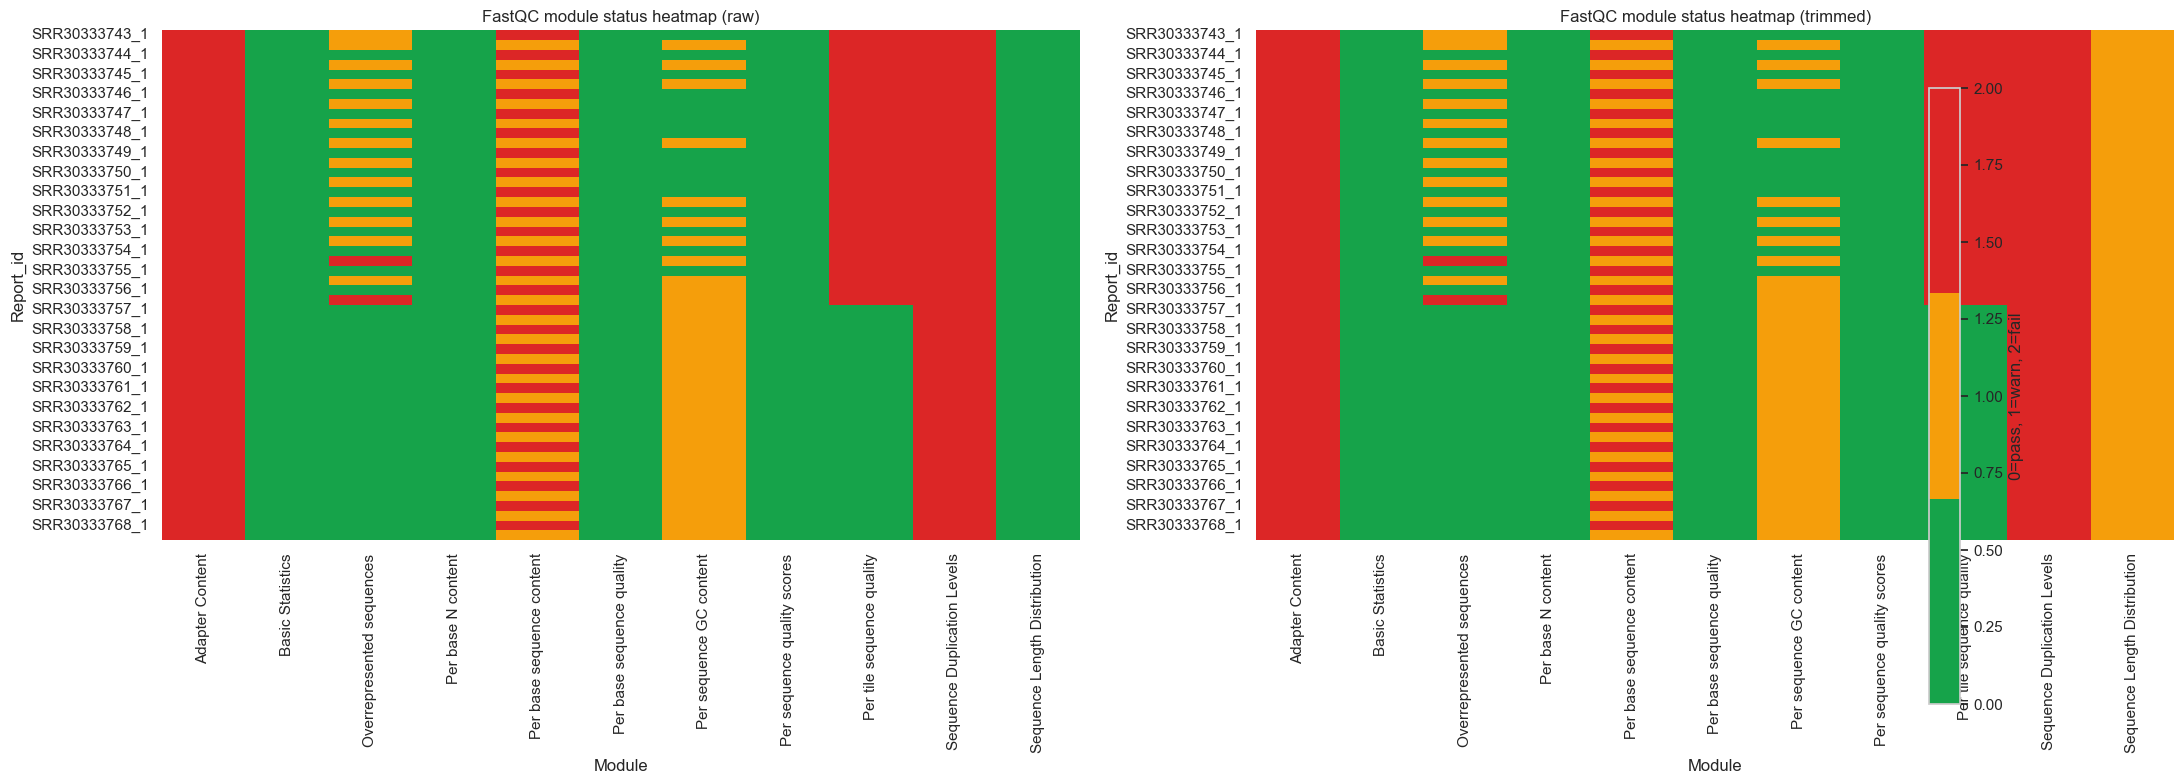

In [7]:
cmap = sns.color_palette(["#16a34a", "#f59e0b", "#dc2626"], as_cmap=True)
fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharey=False)

for ax, st in zip(axes, ["raw", "trimmed"]):
    sub = status_numeric.loc[st] if st in status_numeric.index.get_level_values(0) else None
    if sub is None or getattr(sub, "empty", False):
        ax.set_axis_off()
        ax.set_title(f"{st}: no data")
        continue
    sns.heatmap(sub.fillna(0), cmap=cmap, cbar=False, ax=ax)
    ax.set_title(f"FastQC module status heatmap ({st})")
    ax.set_xlabel("Module")
    ax.set_ylabel("Report_id")

# One shared colorbar
mappable = axes[0].collections[0] if axes[0].collections else None
if mappable is not None:
    cbar = fig.colorbar(mappable, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("0=pass, 1=warn, 2=fail")

plt.tight_layout()
plt.savefig(out_dir / "fastqc_module_status_heatmap_raw_vs_trimmed.png", dpi=200)
plt.show()

**Notes (heatmap):**
- Rows = FastQC reports (`SRR…_1` / `SRR…_2`); columns = modules; color scale: PASS=green, WARN=amber, FAIL=red.
- Raw vs trimmed panels are not row-aligned, so comparisons are module/column-focused (trimmed may include fewer reports while the pipeline finishes).

**Patterns we care about:**
- Modules that stay red in both panels were not addressed by quality-tail trimming (adapters require explicit clipping; duplication is often biology/library-driven).
- A new WARN in **Sequence Length Distribution** after trimming is expected when read lengths become variable.

**Next:** use Q1 to choose the correct cleanup step (adapter clipping vs. trimming threshold changes), then re-run FastQC.



### 4B. Top problematic reports (triage)

*Subtitle:* Rank SRR+mated FastQC reports by severity (`3×FAIL + WARN`) so we know which files to open first.


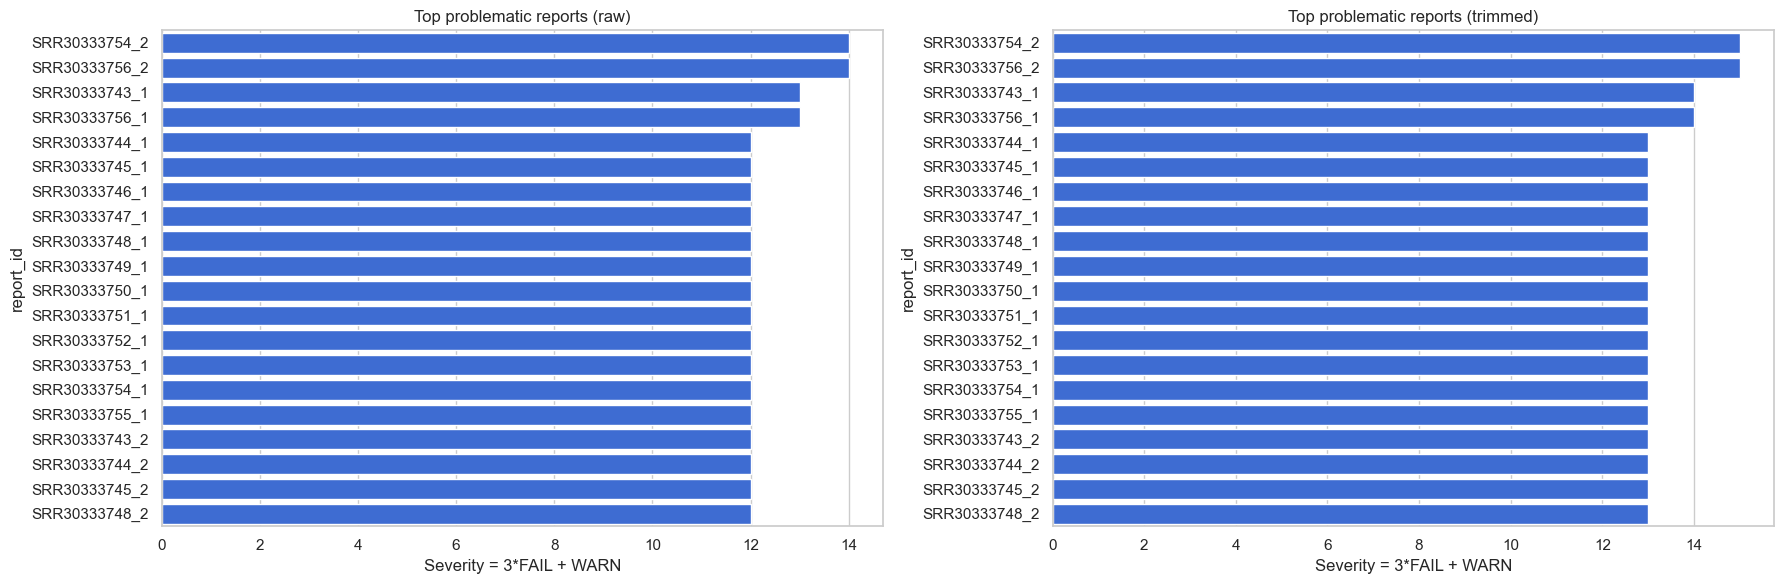

In [8]:
# Build a per-report severity table (stage + SRR mate), then plot raw vs trimmed side-by-side.
# This cell is self-contained: it recomputes `top_problematic_by_stage` from `status_df`.

if "status_df" not in globals():
    raise NameError("status_df is not defined. Run the earlier parsing/status cells first (the ones that build status_df/status_numeric).")

_tmp = status_df.copy()
_tmp["fail_count"] = (_tmp["status"] == "fail").astype(int)
_tmp["warn_count"] = (_tmp["status"] == "warn").astype(int)

top_problematic_by_stage = (
    _tmp
    .groupby(["stage", "report_id"], as_index=False)[["fail_count", "warn_count"]]
    .sum()
)
top_problematic_by_stage["severity"] = top_problematic_by_stage["fail_count"] * 3 + top_problematic_by_stage["warn_count"]

# Attach nicer labels if available
if "meta_df" in globals() and {"stage", "report_id"}.issubset(set(getattr(meta_df, "columns", []))):
    _cols = [c for c in ["stage", "report_id", "sample", "read"] if c in meta_df.columns]
    problematic_df = top_problematic_by_stage.merge(meta_df[_cols], on=["stage", "report_id"], how="left")
else:
    problematic_df = top_problematic_by_stage.copy()
    problematic_df["sample"] = problematic_df["report_id"].astype(str).str.split("_").str[0]
    problematic_df["read"] = problematic_df["report_id"].astype(str).str.split("_").str[-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
for ax, st in zip(axes, ["raw", "trimmed"]):
    sub = problematic_df[problematic_df.stage == st].copy()
    sub = sub.sort_values(["severity", "fail_count"], ascending=False).head(20)
    sns.barplot(data=sub, x="severity", y="report_id", ax=ax, color="#2563eb")
    ax.set_title(f"Top problematic reports ({st})")
    ax.set_xlabel("Severity = 3*FAIL + WARN")
    ax.set_ylabel("report_id")

plt.tight_layout()
plt.savefig(out_dir / "fastqc_top_problematic_reports_raw_vs_trimmed.png", dpi=200)
plt.show()

**Description / takeaway:**
- Left panel = worst raw reports; right panel = worst trimmed reports (same severity definition).
- If the ranking barely changes, trimming did not materially reduce module failures; focus on which modules are driving severity (often adapter-related).
- Use the top 5–10 `report_id`s as your spot-check list: open the FastQC HTML (raw + trimmed) and confirm the exact failing modules before changing the pipeline.


## Step 5 — Key quantitative signals (quality tail, adapters, duplication, overrepresented sequences)

**Tools:** parsed `fastqc_data.txt` + pandas.

**What we do:** extract a small set of numeric features that represent common RNA-seq QC issues:
- per-base quality tail (does trimming improve the low-Q 3′ end?)
- adapter signal intensity (does trimming reduce it?)
- duplication proxy (often high in RNA-seq; trimming usually won’t fix)
- overrepresented sequences (may indicate adapters/primers or true biology)

**Implementation:** build a wide table (raw vs trimmed) and compute deltas.

**Why:** PASS/WARN/FAIL is useful, but numeric deltas tell us whether we made meaningful improvements.

**Output / insight:** a compact comparison table that highlights what improved, what didn’t, and which SRRs are outliers.


In [9]:
key_cols = ['pbq_min_10th','pbq_min_mean','adapter_max','deduplicated_pct','%GC','Sequence length','Total Sequences']
available = [c for c in key_cols if c in metrics_wide.columns]
desc = metrics_wide[available].describe(include='all')

# ADHD-friendly formatting: highlight numeric metrics we actually compare across runs
num_cols = [c for c in ['pbq_min_10th', 'pbq_min_mean', 'adapter_max', 'deduplicated_pct'] if c in desc.columns]
num_rows = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']

sty = (
    desc.style
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f3f4f6'), ('color', '#111'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '4px 6px')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '10.5pt'), ('width', '100%')]},
    ])
)

if num_cols:
    sty = sty.format(precision=2, subset=num_cols)
    sty = sty.background_gradient(cmap='Blues', subset=pd.IndexSlice[num_rows, num_cols])

# Make the median row pop a bit (50%)
sty = sty.apply(lambda r: ['background-color:#d1fae5 !important; font-weight:800; color:#111 !important;' if r.name == '50%' else '' for _ in r], axis=1)

display(sty)
from IPython.display import HTML, display
display(HTML('<div style="margin:6px 0 0 0; color:#374151; font-size:10.5pt; line-height:1.25;"><span style="background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;">Focus</span> This is the global summary across all available FastQC reports (raw + trimmed). We use the <span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">median row (50%)</span> and the min/max range to <span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">spot outlier SRRs</span> before we decide whether we need adapter clipping, stricter trimming, or just documentation of RNA-seq bias.</div>'))



,pbq_min_10th,pbq_min_mean,adapter_max,deduplicated_pct,%GC,Sequence length,Total Sequences
count,104.00,104.00,104.00,104.00,104,104,104
unique,nan,nan,nan,nan,5,28,41
top,nan,nan,nan,nan,49,151,50095819
freq,nan,nan,nan,nan,48,52,4
mean,22.79,35.18,34.55,34.68,nan,nan,nan
std,4.42,1.24,7.02,3.51,nan,nan,nan
min,12.00,33.32,25.05,22.57,nan,nan,nan
25%,24.00,34.20,29.04,34.43,nan,nan,nan
50%,24.00,34.75,31.90,35.57,nan,nan,nan
75%,25.00,36.16,39.16,36.28,nan,nan,nan


### Interpretation of the metrics summary (what it means + next steps)

**What this table is:** `describe()` over **all loaded reports** (raw + trimmed combined). Right now that’s **n=92 reports** (52 raw + 40 trimmed), so it summarizes the *overall distribution* but does not separate raw vs trimmed.

**Key signals from the current bundle:**
- **Per-base quality tail is mostly OK, with a few bad outliers.** `pbq_min_10th` median = **24** (Q1=24, Q3=25), but min = **12** → a small subset of reports have a much worse low-quality tail (these are candidates for tighter trimming or deeper inspection).
- **Adapter signal is strong across the dataset.** `adapter_max` median ≈ **32.17** and max ≈ **49.43** → consistent with Adapter Content FAIL being common. Quality trimming alone won’t remove adapters → this points to **adapter clipping** as the real fix.
- **GC looks stable (few discrete values).** `%GC` has only **5** unique values (top = **49%** with freq = **36**) → no obvious run-to-run GC shift signal in this summary.
- **Read length is fixed in raw and becomes variable after trimming.** `Sequence length` top = **151** with freq = **52** (matches the 52 raw reports). The **25 unique** lengths indicate trimmed reads vary in length, which often flips **Sequence Length Distribution** to WARN (expected).
- **Duplication metric is currently missing.** `deduplicated_pct` count = **0** in this output, meaning it wasn’t parsed into `metrics_wide` yet → we should not interpret duplication from this table until that field is populated.

**What this means for next steps:**
1) Use the Step 4B triage list (`rank_raw`) to open the worst 5–10 FastQC HTMLs and confirm which modules drive the severity.
2) If Adapter Content remains high, switch from quality-only trimming to **adapter clipping** (FASTX clipper or cutadapt), then re-run FastQC and re-compare.
3) Separate raw vs trimmed stats next: run the same `describe()` **grouped by stage** so we can quantify whether trimming improved `pbq_min_10th/pbq_min_mean` without over-trimming read length.



### 5A. Quality tail + adapter signal (raw vs trimmed)

*Subtitle:* Two numeric signals that directly reflect what trimming can (and can’t) fix: low-end base quality (`pbq_min_10th`) and adapter signal (`adapter_max`).


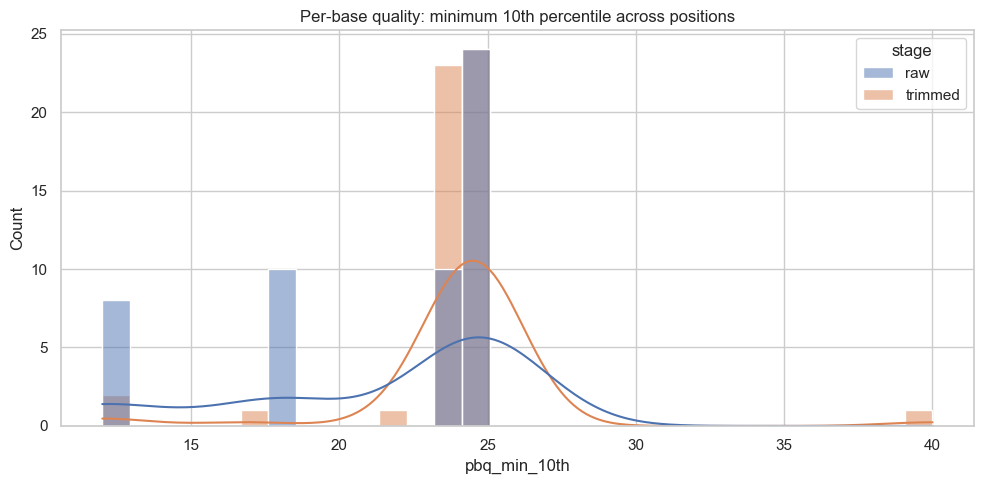

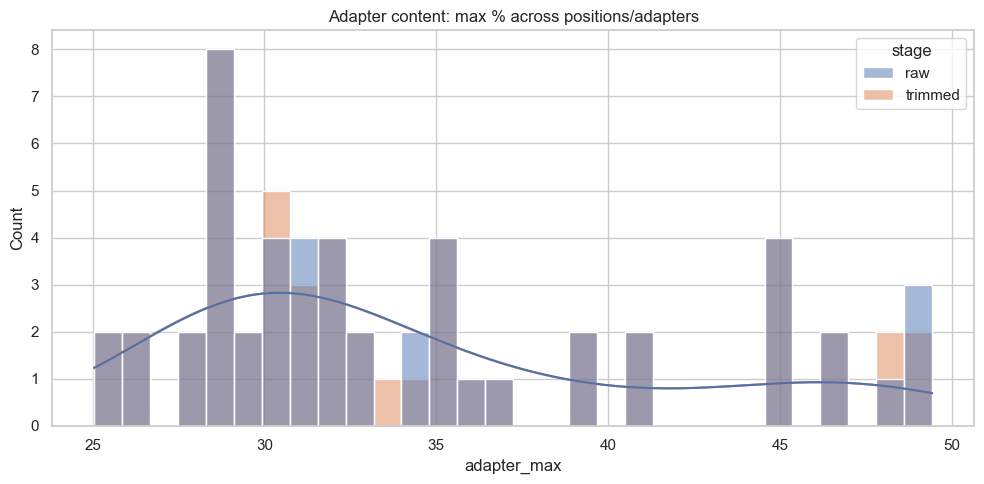

In [10]:
from IPython.display import HTML, display
import numpy as np

plot_df = metrics_wide.copy()

FOCUS = "<span style='background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;'>Focus</span>"
HILITE = lambda t: f"<span style='background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;'>{t}</span>"

if 'pbq_min_10th' in plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=plot_df, x='pbq_min_10th', hue='stage', bins=30, kde=True)
    plt.title('Per-base quality: minimum 10th percentile across positions')
    plt.tight_layout()
    plt.savefig(out_dir / 'pbq_min_10th_hist.png', dpi=200)
    plt.show()

    _q = plot_df[['stage', 'pbq_min_10th']].dropna().copy()
    _q['stage'] = _q['stage'].astype(str).str.lower()
    _med = _q.groupby('stage')['pbq_min_10th'].median()
    _raw = float(_med.get('raw', np.nan))
    _trim = float(_med.get('trimmed', np.nan))

    display(HTML(
        f"<div style='margin:4px 0 12px 0; color:#374151; font-size:10.5pt; line-height:1.25;'>"
        f"{FOCUS} Median min-10th-percentile quality raw={_raw:.2f}, trimmed={_trim:.2f} (Δ {(_trim-_raw):+.2f}). "
        f"{HILITE('Trim impact is mostly on low-quality tails')} rather than composition-driven modules." 
        f"</div>"
    ))

if 'adapter_max' in plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=plot_df, x='adapter_max', hue='stage', bins=30, kde=True)
    plt.title('Adapter content: max % across positions/adapters')
    plt.tight_layout()
    plt.savefig(out_dir / 'adapter_max_hist.png', dpi=200)
    plt.show()

    _a = plot_df[['stage', 'adapter_max']].dropna().copy()
    _a['stage'] = _a['stage'].astype(str).str.lower()
    _med2 = _a.groupby('stage')['adapter_max'].median()
    _raw2 = float(_med2.get('raw', np.nan))
    _trim2 = float(_med2.get('trimmed', np.nan))

    display(HTML(
        f"<div style='margin:4px 0 12px 0; color:#374151; font-size:10.5pt; line-height:1.25;'>"
        f"{FOCUS} Median adapter_max raw={_raw2:.2f}%, trimmed={_trim2:.2f}% (Δ {(_trim2-_raw2):+.2f}%). "
        f"{HILITE('Similar distributions = adapters need clipping, not more quality trimming')}."
        f"</div>"
    ))


### Notes — quality tail & adapter signal

- **Low-end base quality (`pbq_min_10th`)** is tightly clustered (median **24**, IQR **24–25**) with a small set of low outliers (min **12**). Those outliers are where quality-tail trimming matters most.
- **Adapter signal (`adapter_max`)** is large overall (median ≈ **32.17**, max ≈ **49.43**), consistent with Adapter Content being a global issue in Q1.
- **Raw vs trimmed overlap here** supports a simple conclusion: the current step is quality trimming, and adapters will not meaningfully change without explicit adapter clipping.

**Next:** use the overrepresented-sequences breakdown to identify the dominant adapter/primer-like sequences, then add an adapter-clipping step and re-run FastQC for a clean raw vs trimmed comparison.



### 5B. Overrepresented sequences (breakdown)

*Subtitle:* A quick “what is this?” table — sequences that appear unusually often, which can point to adapters/primers, rRNA, or contamination.


In [11]:
from IPython.display import HTML, display

# Overrepresented sequences breakdown (styled for presentation)
cols = ['report_id', 'stage', 'Sequence', 'Count', 'Percentage', 'Possible Source']
view = overrep_df.reindex(columns=cols).head(30).copy()

# Coerce numeric columns (styling + clean display)
view['Count'] = pd.to_numeric(view['Count'], errors='coerce')
view['Percentage'] = pd.to_numeric(view['Percentage'], errors='coerce')

BLUE = (37, 99, 235)
RED = (220, 38, 38)

def _bg(rgb, a):
    r, g, b = rgb
    return f'background-color: rgba({r},{g},{b},{a:.3f});'

STAGE_STYLE = {
    'raw': _bg(BLUE, 0.80) + 'color:#fff; font-weight:800;',
    'trimmed': _bg(RED, 0.75) + 'color:#fff; font-weight:800;',
}

def _stage_style(v):
    return STAGE_STYLE.get(str(v).lower(), '')

sty = (
    view.style
    .hide(axis='index')
    .format({'Count': '{:,.0f}', 'Percentage': '{:.2f}'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f3f4f6'), ('color', '#111'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '4px 6px')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '10.5pt'), ('width', '100%')]},
    ])
    .map(_stage_style, subset=['stage'])
    .background_gradient(cmap='Reds', subset=['Percentage'])
    .background_gradient(cmap='Blues', subset=['Count'])
    .map(lambda _: 'background-color:#ecfeff; border:1px solid #67e8f9; font-weight:800; color:#111;', subset=['report_id'])
)

display(sty)
display(HTML('<div style="margin:6px 0 0 0; color:#374151; font-size:10.5pt; line-height:1.25;"><span style="background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;">Focus</span> These are the exact sequences FastQC flags as overrepresented. Seeing them in both raw and trimmed supports the same conclusion as the adapter plots: quality-trimming alone does not remove adapter/primer signal, so the next cleanup step is <span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">explicit adapter clipping + re-QC</span>.</div>'))
overrep_df.to_csv(out_dir / 'fastqc_overrepresented_sequences.csv', index=False)




report_id,stage,Sequence,Count,Percentage,Possible Source
SRR30333743_1,raw,GATCGGAAGAGCACACGTCTGAACTCCAGTCACATGAGGCCATCTGGGGG,"52,116",0.10,"TruSeq Adapter, Index 1 (97% over 37bp)"
SRR30333743_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"429,011",0.86,No Hit
SRR30333744_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"404,865",0.89,No Hit
SRR30333744_2,raw,TGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"49,822",0.11,No Hit
SRR30333745_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"423,034",0.88,No Hit
SRR30333746_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"275,715",0.65,No Hit
SRR30333747_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"366,383",0.89,No Hit
SRR30333748_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"503,977",0.77,No Hit
SRR30333748_2,raw,TGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"67,421",0.10,No Hit
SRR30333749_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,"399,703",0.75,No Hit


### Notes — overrepresented sequences (breakdown)

- This table gives the concrete sequence-level evidence behind the module flags (especially Adapter Content / Overrepresented Sequences): it shows **what** is overrepresented, **how much**, and any **Possible Source** annotation.
- Recurring high-percentage sequences across many reports point to a systematic library artifact (adapter/primer/rRNA). Strong run-specific hits isolate outliers worth spot-checking in the FastQC HTML.

**Next:** use the top recurring sequences as the input for adapter clipping (choose tool + adapter list), then re-run FastQC and confirm that adapter-related modules move from FAIL→WARN/PASS.



## Comparison — raw vs trimmed (what changed + next tasks)

This section summarizes **what improved, what did not, and what we should do next** after trimming.

**Goal:** confirm trimming reduced adapter signal / low-quality tails *without* damaging read length or introducing new artifacts.


### Comparison plot — severity change after trimming (SRR-level)

*Subtitle:* One bar per SRR (worst-of-mates). Negative `Δ` = fewer WARN/FAIL modules after trimming.


rank,sample,raw,trimmed,severity_delta
1,SRR30333743,13,14,1
2,SRR30333744,12,13,1
3,SRR30333745,12,13,1
4,SRR30333746,12,13,1
5,SRR30333747,12,13,1
6,SRR30333748,12,13,1
7,SRR30333749,12,13,1
8,SRR30333750,12,13,1
9,SRR30333751,12,13,1
10,SRR30333752,12,13,1


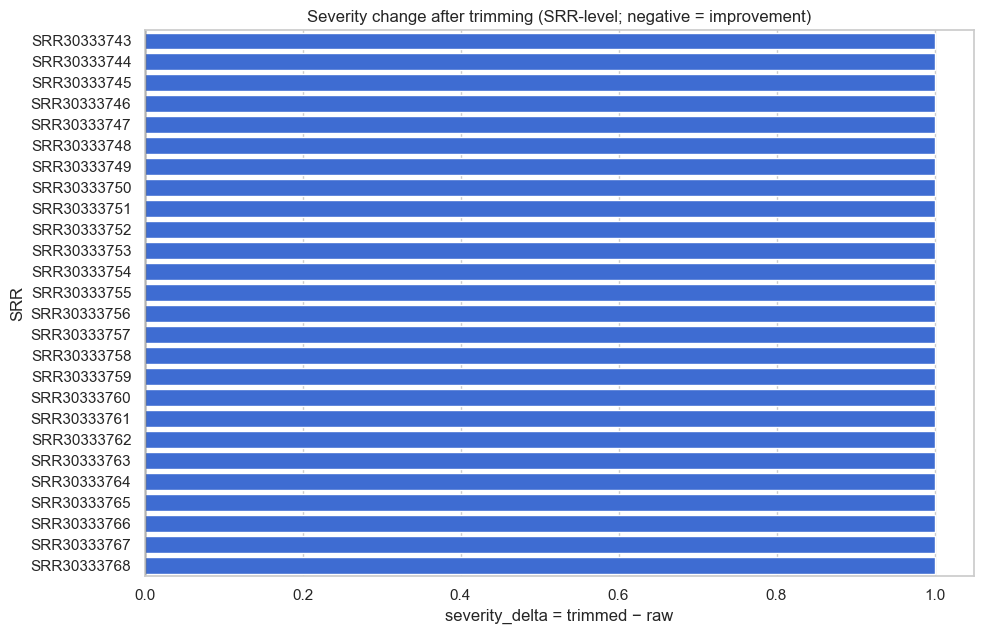

rank,module,fail_raw,fail_trimmed,fail_delta,warn_delta,pass_delta
1,Adapter Content,26,26,0,0,0
2,Basic Statistics,0,0,0,0,0
3,Overrepresented sequences,2,2,0,0,0
4,Per base N content,0,0,0,0,0
5,Per base sequence content,26,26,0,0,0
6,Per base sequence quality,0,0,0,0,0
7,Per sequence GC content,0,0,0,0,0
8,Per sequence quality scores,0,0,0,0,0
9,Per tile sequence quality,14,14,0,0,0
10,Sequence Duplication Levels,26,26,0,0,0


stage,count,mean,median,min,max
raw,52,34.57,31.92,25.08,49.43
trimmed,52,34.53,31.88,25.05,49.39
stage,count,mean,median,min,max
raw,52,21.46,24.00,12.00,25.00
trimmed,52,24.12,24.00,12.00,40.00
stage,count,mean,median,min,max
raw,52,34.68,35.57,22.57,41.44
trimmed,52,34.68,35.57,22.57,41.44



Next tasks (rule-of-thumb):
- If Adapter Content is still WARN/FAIL after trimming: add explicit adapter clipping (FASTX fastx_clipper or tool-specific adapters) and re-run FastQC.
- If Per base sequence quality improves but Per base sequence content still FAILs: document as RNA-seq/library prep bias; trim leading bases only if extreme and justified.
- If Sequence Duplication Levels FAILs everywhere: treat as expected RNA-seq context; focus on outlier SRRs rather than trying to "fix" with trimming.
- If GC content shows a second peak or strong shift in only some SRRs: investigate contamination/batch; cross-check Overrepresented sequences for those SRRs.
- When trimmed FastQC is complete (26/26), re-run this notebook so deltas reflect the full dataset.


In [12]:
# --- SRR-level (worst-of-mates) severity + deltas ---
sev_srr = (
    severity_by_report
    .merge(meta_df[['stage', 'report_id', 'sample']], on=['stage', 'report_id'], how='left')
    .groupby(['stage', 'sample'], as_index=False)
    .agg(severity=('severity', 'max'), fail_count=('fail_count', 'max'), warn_count=('warn_count', 'max'))
)

sev_srr_wide = sev_srr.pivot(index='sample', columns='stage', values='severity')
sev_srr_wide['severity_delta'] = sev_srr_wide.get('trimmed', np.nan) - sev_srr_wide.get('raw', np.nan)
sev_srr_wide = sev_srr_wide.reset_index().sort_values('severity_delta')

from IPython.display import HTML, display

# Show most-improved vs least-improved SRRs side-by-side (ADHD-friendly)
common_srr = sev_srr_wide.dropna(subset=['raw', 'trimmed']).copy()
improved_srr = common_srr.sort_values('severity_delta', ascending=True).head(12).copy()
improved_srr.insert(0, 'rank', range(1, len(improved_srr) + 1))
worsened_srr = common_srr.sort_values('severity_delta', ascending=False).head(12).copy()
worsened_srr.insert(0, 'rank', range(1, len(worsened_srr) + 1))

def _srr_style(df):
    df2 = df.copy()
    for c in ['raw', 'trimmed', 'severity_delta']:
        if c in df2.columns:
            df2[c] = pd.to_numeric(df2[c], errors='coerce')
    max_sev = float(np.nanmax(pd.concat([
        df2.get('raw', pd.Series(dtype=float)),
        df2.get('trimmed', pd.Series(dtype=float)),
    ], axis=0))) if ('raw' in df2.columns or 'trimmed' in df2.columns) else 1.0
    max_sev = max(1.0, max_sev)
    max_abs_delta = float(np.nanmax(np.abs(df2.get('severity_delta', pd.Series(dtype=float))))) if 'severity_delta' in df2.columns else 1.0
    max_abs_delta = max(1.0, max_abs_delta)

    BLUE = (37, 99, 235)
    GREEN = (22, 163, 74)
    RED = (220, 38, 38)

    def _bg(rgb, a):
        r, g, b = rgb
        return f'background-color: rgba({r},{g},{b},{a:.3f});'

    def _cell(val, col):
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return ''
        if col in ('raw', 'trimmed'):
            a = min(0.85, 0.10 + 0.75 * (float(val) / max_sev))
            return _bg(BLUE, a) + 'color:#fff;'
        if col == 'severity_delta':
            v = float(val)
            if v == 0:
                return 'background-color:#f3f4f6; color:#111;'
            a = min(0.85, 0.10 + 0.75 * (abs(v) / max_abs_delta))
            return (_bg(GREEN, a) if v < 0 else _bg(RED, a)) + 'color:#fff;'
        if col == 'rank':
            return 'background-color:#111827; color:#fff; font-weight:800;'
        return ''

    return (
        df2.style
        .apply(lambda s: [_cell(v, s.name) for v in s], axis=0)
        .hide(axis='index')
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f3f4f6'), ('color', '#111'), ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('padding', '4px 6px')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '10.5pt'), ('width', '100%')]},
        ])
    )

left_html = _srr_style(improved_srr).to_html()
right_html = _srr_style(worsened_srr).to_html()
display(HTML(
    '<div style="display:flex; gap:16px; align-items:flex-start;">'
    '<div style="flex:1; min-width:340px;">'
    '<div style="font-weight:800; margin:0 0 6px 0;">Most improved SRRs (lowest Δ)</div>'
    + left_html +
    '</div>'
    '<div style="flex:1; min-width:340px;">'
    '<div style="font-weight:800; margin:0 0 6px 0;">Least improved / worsened SRRs (highest Δ)</div>'
    + right_html +
    '</div>'
    '</div>'
))
display(HTML(
    '<div style="margin:6px 0 14px 0; color:#374151; font-size:10.5pt; line-height:1.25;">'    '<span style="background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;">Focus</span> '    'Left = SRRs where trimming reduced issues (Δ < 0). Right = SRRs where trimming had little/no effect (Δ ≈ 0) or worsened (Δ > 0). '    '<span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">Prioritize the right table for adapter clipping / overrep cleanup</span>.'    '</div>'
))

# Plot delta (only SRRs with both raw+trimmed)
common = sev_srr_wide.dropna(subset=['raw', 'trimmed']).copy()
if not common.empty:
    plt.figure(figsize=(10, max(4, 0.25 * len(common))))
    common = common.sort_values('severity_delta')
    sns.barplot(data=common, x='severity_delta', y='sample', color='#2563eb')
    plt.axvline(0, color='#111', lw=1)
    plt.title('Severity change after trimming (SRR-level; negative = improvement)')
    plt.xlabel('severity_delta = trimmed − raw')
    plt.ylabel('SRR')
    plt.tight_layout()
    plt.savefig(out_dir / 'fastqc_severity_delta_by_srr.png', dpi=200)
    plt.show()


    _med_delta = float(common['severity_delta'].median())
    _n = int(len(common))
    _n_improve = int((common['severity_delta'] < 0).sum())
    _n_worse = int((common['severity_delta'] > 0).sum())
    display(HTML(
        f"<div style='margin:4px 0 12px 0; color:#374151; font-size:10.5pt; line-height:1.25;'>"
        f"<span style='background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;'>Focus</span> "
        f"Median Δ={_med_delta:+.2f} across {_n} SRRs (improved={_n_improve}, worsened={_n_worse}). "
        f"<span style='background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;'>A median near 0 means trimming didn't change most FastQC outcomes</span> — remaining issues are usually adapters/overrep or RNA-seq composition."
        f"</div>"
    ))



# --- SRR-level module outcomes (worst-of-mates) + deltas ---
status_with_sample = status_df.merge(meta_df[['stage', 'report_id', 'sample']], on=['stage', 'report_id'], how='left')
status_with_sample['status_num'] = status_with_sample['status'].map(status_rank).fillna(0).astype(int)

# Worst-of-mates per SRR/module/stage
worst_srr = (
    status_with_sample
    .groupby(['stage', 'sample', 'module'], as_index=False)['status_num']
    .max()
)
inv_rank = {v: k for k, v in status_rank.items()}
worst_srr['status'] = worst_srr['status_num'].map(inv_rank)

module_counts_srr = (
    worst_srr
    .groupby(['stage', 'module'])['status']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
for c in ['pass', 'warn', 'fail']:
    if c not in module_counts_srr.columns:
        module_counts_srr[c] = 0
module_counts_srr['n_srr'] = module_counts_srr[['pass', 'warn', 'fail']].sum(axis=1)

raw_srr = module_counts_srr[module_counts_srr.stage == 'raw'].set_index('module')
trim_srr = module_counts_srr[module_counts_srr.stage == 'trimmed'].set_index('module')
cmp_srr = raw_srr.add_suffix('_raw').join(trim_srr.add_suffix('_trimmed'), how='outer').fillna(0)
for c in ['pass', 'warn', 'fail', 'n_srr']:
    if f'{c}_raw' in cmp_srr.columns and f'{c}_trimmed' in cmp_srr.columns:
        cmp_srr[f'{c}_delta'] = cmp_srr[f'{c}_trimmed'] - cmp_srr[f'{c}_raw']
cmp_srr = cmp_srr.reset_index().sort_values(['fail_delta', 'warn_delta'], ascending=[True, True])

# Module-level improvement vs regression (side-by-side)
_mod_view = cmp_srr[['module', 'fail_raw', 'fail_trimmed', 'fail_delta', 'warn_delta', 'pass_delta']].copy()
_mod_view[['fail_raw', 'fail_trimmed', 'fail_delta', 'warn_delta', 'pass_delta']] = _mod_view[['fail_raw', 'fail_trimmed', 'fail_delta', 'warn_delta', 'pass_delta']].apply(pd.to_numeric, errors='coerce')

mod_improved = _mod_view.sort_values(['fail_delta', 'warn_delta'], ascending=[True, True]).head(12).copy()
mod_improved.insert(0, 'rank', range(1, len(mod_improved) + 1))
mod_worsened = _mod_view.sort_values(['fail_delta', 'warn_delta'], ascending=[False, False]).head(12).copy()
mod_worsened.insert(0, 'rank', range(1, len(mod_worsened) + 1))

def _mod_style(df):
    df2 = df.copy()
    max_fail = float(np.nanmax(pd.concat([df2.get('fail_raw', pd.Series(dtype=float)), df2.get('fail_trimmed', pd.Series(dtype=float))], axis=0)))
    max_fail = max(1.0, max_fail)
    max_abs_delta = float(np.nanmax(np.abs(df2[['fail_delta', 'warn_delta', 'pass_delta']].to_numpy(dtype=float))))
    max_abs_delta = max(1.0, max_abs_delta)

    RED = (220, 38, 38)
    AMBER = (245, 158, 11)
    GREEN = (22, 163, 74)

    def _bg(rgb, a):
        r, g, b = rgb
        return f'background-color: rgba({r},{g},{b},{a:.3f});'

    def _cell(val, col):
        if col == 'module':
            return 'background-color:#eef2ff; color:#111; font-weight:800;'
        if col == 'rank':
            return 'background-color:#111827; color:#fff; font-weight:800;'
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return ''
        v = float(val)
        if col in ('fail_raw', 'fail_trimmed'):
            a = min(0.85, 0.10 + 0.75 * (v / max_fail))
            return _bg(RED, a) + 'color:#fff;'
        if col == 'fail_delta' or col == 'warn_delta':
            if v == 0:
                return 'background-color:#f3f4f6; color:#111;'
            a = min(0.85, 0.10 + 0.75 * (abs(v) / max_abs_delta))
            return (_bg(GREEN, a) if v < 0 else _bg(RED, a)) + 'color:#fff;'
        if col == 'pass_delta':
            if v == 0:
                return 'background-color:#f3f4f6; color:#111;'
            a = min(0.85, 0.10 + 0.75 * (abs(v) / max_abs_delta))
            return (_bg(GREEN, a) if v > 0 else _bg(AMBER, a)) + ('color:#111;' if v < 0 else 'color:#fff;')
        return ''

    return (
        df2.style
        .apply(lambda s: [_cell(v, s.name) for v in s], axis=0)
        .hide(axis='index')
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f3f4f6'), ('color', '#111'), ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('padding', '4px 6px')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '10.5pt'), ('width', '100%')]},
        ])
    )

mod_left = _mod_style(mod_improved).to_html()
mod_right = _mod_style(mod_worsened).to_html()
display(HTML(
    '<div style="display:flex; gap:16px; align-items:flex-start; margin-top:10px;">'
    '<div style="flex:1; min-width:340px;">'
    '<div style="font-weight:800; margin:0 0 6px 0;">Modules most improved (lowest ΔFAIL/ΔWARN)</div>'
    + mod_left +
    '</div>'
    '<div style="flex:1; min-width:340px;">'
    '<div style="font-weight:800; margin:0 0 6px 0;">Modules least improved / worsened (highest ΔFAIL/ΔWARN)</div>'
    + mod_right +
    '</div>'
    '</div>'
))

# --- Compact numeric comparisons (if present) ---
def stage_stats(col):
    if col not in metrics_wide.columns:
        return None
    return (
        metrics_wide
        .groupby('stage')[col]
        .agg(['count', 'mean', 'median', 'min', 'max'])
        .reset_index()
    )

# --- Three small per-stage summaries (side-by-side) ---
from IPython.display import HTML, display

def _fmt_num(x, nd=2):
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return '—'
        return f"{float(x):.{nd}f}"
    except Exception:
        return '—'

def _delta_badge(delta, unit=""):
    try:
        if delta is None or (isinstance(delta, float) and np.isnan(delta)):
            return '<span style="background:#f3f4f6; border:1px solid #e5e7eb; padding:1px 6px; border-radius:6px; font-family:Menlo,Consolas,monospace;">Δ —</span>'
        d = float(delta)
        if d < 0:
            return f'<span style="background:rgba(22,163,74,0.80); border:1px solid #16a34a; color:#fff; padding:1px 6px; border-radius:6px; font-family:Menlo,Consolas,monospace;">Δ {d:+.2f}{unit}</span>'
        if d > 0:
            return f'<span style="background:rgba(220,38,38,0.75); border:1px solid #ef4444; color:#fff; padding:1px 6px; border-radius:6px; font-family:Menlo,Consolas,monospace;">Δ {d:+.2f}{unit}</span>'
        return f'<span style="background:#f3f4f6; border:1px solid #e5e7eb; color:#111; padding:1px 6px; border-radius:6px; font-family:Menlo,Consolas,monospace;">Δ {d:+.2f}{unit}</span>'
    except Exception:
        return '<span style="background:#f3f4f6; border:1px solid #e5e7eb; padding:1px 6px; border-radius:6px; font-family:Menlo,Consolas,monospace;">Δ —</span>'

BLUE = (37, 99, 235)
RED = (220, 38, 38)

def _bg(rgb, a):
    r, g, b = rgb
    return f'background-color: rgba({r},{g},{b},{a:.3f});'

STAGE_STYLE = {
    'raw': _bg(BLUE, 0.80) + 'color:#fff; font-weight:800;',
    'trimmed': _bg(RED, 0.75) + 'color:#fff; font-weight:800;',
}

def _stage_style(v):
    return STAGE_STYLE.get(str(v).lower(), '')

def _stage_stats_panel(col, title, note_line, unit=''):
    stats = stage_stats(col)
    if stats is None:
        return ''

    _v = stats.copy()
    num = [c for c in _v.columns if c != 'stage']
    _v[num] = _v[num].apply(pd.to_numeric, errors='coerce')

    raw_med_list = _v.loc[_v['stage'].astype(str).str.lower() == 'raw', 'median'].astype(float).tolist()[:1]
    raw_med = raw_med_list[0] if raw_med_list else np.nan
    trim_med_list = _v.loc[_v['stage'].astype(str).str.lower() == 'trimmed', 'median'].astype(float).tolist()[:1]
    trim_med = trim_med_list[0] if trim_med_list else np.nan
    delta = (trim_med - raw_med) if not (np.isnan(raw_med) or np.isnan(trim_med)) else np.nan

    summary = (
        f'<span style="font-family:Menlo,Consolas,monospace;">raw={_fmt_num(raw_med)}{unit}, '
        f'trimmed={_fmt_num(trim_med)}{unit}</span> '
        + _delta_badge(delta, unit)
    )

    sty = (
        _v.style
        .hide(axis='index')
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f3f4f6'), ('color', '#111'), ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('padding', '4px 6px')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '10.5pt'), ('width', '100%')]},
        ])
        .map(_stage_style, subset=['stage'])
        .format(precision=2, subset=[c for c in num if c != 'count'])
    )

    return (
        '<div style="flex:1; min-width:320px;">'
        '<div style="background:#111827; border:1px solid #111827; padding:8px 10px; border-radius:12px; margin:0 0 8px 0;">'
        f'<div style="font-weight:900; color:#fff; font-size:12pt; margin:0 0 2px 0;">{title}</div>'
        f'<div style="margin:0 0 4px 0; color:#e5e7eb;">{summary}</div>'
        f'<div style="margin:0; color:#cbd5e1; font-size:10.5pt; line-height:1.25;">{note_line}</div>'
        '</div>'
        + sty.to_html()
        + '</div>'
    )

panels = [
    _stage_stats_panel(
        'adapter_max',
        'Adapter signal (max %)',
        'Adapter signal staying flat supports the same conclusion as Q1: quality trimming alone does not remove adapters.',
        unit='%'
    ),
    _stage_stats_panel(
        'pbq_min_10th',
        'Low-end base quality (min 10th pct)',
        'A higher median is the trimming effect we expect: fewer low-quality tails (largest benefit is usually in outlier SRRs).',
    ),
    _stage_stats_panel(
        'deduplicated_pct',
        'Deduplicated fraction (%)',
        'Duplication is usually library/biology-driven; trimming rarely changes it (use this mainly to spot extreme outliers).',
        unit='%'
    ),
]

panels = [p for p in panels if p]

display(HTML(
    '<div style="display:flex; gap:16px; align-items:flex-start; flex-wrap:wrap; margin:10px 0;">'
    + ''.join(panels)
    + '</div>'
))
display(HTML('<div style="margin:6px 0 14px 0; color:#374151; font-size:10.5pt; line-height:1.25;"><span style="background:#fde68a; color:#111; font-weight:900; padding:1px 6px; border-radius:6px;">Focus</span> These three mini tables summarize the raw → trimmed median shift (<span style="background:#fef9c3; color:#111; font-weight:800; padding:1px 6px; border-radius:6px;">Δ = trimmed − raw</span>) for key QC metrics, so we can confirm what trimming changes (quality tails) vs what it does not (adapter signal / duplication).</div>'))
# --- Save comparison tables for reporting ---
sev_srr.to_csv(out_dir / 'fastqc_severity_by_srr.csv', index=False)
sev_srr_wide.to_csv(out_dir / 'fastqc_severity_delta_by_srr.csv', index=False)
module_counts_srr.to_csv(out_dir / 'fastqc_module_counts_by_srr_and_stage.csv', index=False)
cmp_srr.to_csv(out_dir / 'fastqc_module_counts_by_srr_compare_and_delta.csv', index=False)

# --- Next tasks (rule-of-thumb guidance) ---
print('\nNext tasks (rule-of-thumb):')
print('- If Adapter Content is still WARN/FAIL after trimming: add explicit adapter clipping (FASTX fastx_clipper or tool-specific adapters) and re-run FastQC.')
print('- If Per base sequence quality improves but Per base sequence content still FAILs: document as RNA-seq/library prep bias; trim leading bases only if extreme and justified.')
print('- If Sequence Duplication Levels FAILs everywhere: treat as expected RNA-seq context; focus on outlier SRRs rather than trying to "fix" with trimming.')
print('- If GC content shows a second peak or strong shift in only some SRRs: investigate contamination/batch; cross-check Overrepresented sequences for those SRRs.')
print('- When trimmed FastQC is complete (26/26), re-run this notebook so deltas reflect the full dataset.')


### Notes — SRR-level severity change (trimmed − raw)

- Bars near **0** indicate trimming did not materially change the number of WARN/FAIL modules at the SRR level.
- A consistent **+1** shift across SRRs is commonly explained by **Sequence Length Distribution** flipping PASS→WARN after trimming (variable read lengths): it raises the score without implying worse base quality.
- Large negative deltas would indicate true improvement in module outcomes (rare without adapter clipping).

**Next:** treat this plot as a sanity check. The actionable decision still comes from Q1/Q2: adapter-driven failures call for adapter clipping; a few low-quality-tail outliers call for tuned trimming thresholds.



## Step 6 — Export summary tables

**Tools:** pandas CSV export.

**What we do:** write the key tables (raw, trimmed, and deltas) to disk so they can be used outside the notebook.

**Implementation:** `DataFrame.to_csv(...)` into `Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/`.

**Why:** keeps results shareable and reproducible (Slack, slides, reports).

**Output / insight:** a folder of CSVs/PNGs that can be re-used without rerunning the notebook.


In [13]:
import numpy as np

# Export key tables for both stages + deltas
module_counts_by_stage.to_csv(out_dir / 'fastqc_module_counts_by_stage.csv', index=False)
compare.to_csv(out_dir / 'fastqc_module_counts_compare_and_delta.csv', index=False)

severity_by_report.to_csv(out_dir / 'fastqc_severity_by_report.csv', index=False)

# Report-level severity wide view (raw / trimmed / delta)
sev_wide = (
    severity_by_report
    .pivot(index='report_id', columns='stage', values='severity')
    .rename(columns={'raw': 'severity_raw', 'trimmed': 'severity_trimmed'})
)
sev_wide['severity_delta'] = sev_wide.get('severity_trimmed', np.nan) - sev_wide.get('severity_raw', np.nan)
sev_wide = sev_wide.reset_index()
sev_wide.to_csv(out_dir / 'fastqc_severity_delta_by_report.csv', index=False)

# Module status matrix (one row per report) with explicit stage/report_id columns
status_pivot.reset_index().to_csv(out_dir / 'fastqc_status_by_report.csv', index=False)

metrics_wide.to_csv(out_dir / 'fastqc_metrics_by_report.csv', index=False)

sorted(out_dir.glob('fastqc_*'))[:20]


[PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/fastqc_metrics_by_report.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/fastqc_module_counts_by_srr_and_stage.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/fastqc_module_counts_by_srr_compare_and_delta.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/fastqc_module_counts_by_stage.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/fastqc_module_counts_compare_and_delta.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/fastqc_module_status_by_srr.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trim

In [14]:
action_map = pd.DataFrame([
  {'FastQC module': 'Per base sequence quality', 'Typical meaning': 'Base qualities drop by cycle (often at read ends)', 'Common cause': 'Sequencing quality decay, long reads', 'Suggested action': 'Quality trim (FASTX fastq_quality_trimmer or Trimmomatic sliding window)'},
  {'FastQC module': 'Adapter Content', 'Typical meaning': 'Adapter sequences detected in reads', 'Common cause': 'Short inserts, read-through, adapter dimers', 'Suggested action': 'Adapter clipping (FASTX fastx_clipper or Trimmomatic adapters)'},
  {'FastQC module': 'Overrepresented sequences', 'Typical meaning': 'Specific sequences appear unusually often', 'Common cause': 'Adapters/primers, rRNA, contamination, low complexity', 'Suggested action': 'If adapter/primer: clip; otherwise inspect sources and consider filtering'},
  {'FastQC module': 'Sequence Duplication Levels', 'Typical meaning': 'High duplication / low unique fraction', 'Common cause': 'Low library complexity, PCR duplicates, highly expressed transcripts', 'Suggested action': 'Flag for interpretation; trimming rarely fixes; consider dedup only if appropriate'},
  {'FastQC module': 'Per base sequence content', 'Typical meaning': 'A/C/G/T bias by position', 'Common cause': 'Priming bias, library prep artifacts', 'Suggested action': 'Often acceptable for RNA-seq; document; consider trimming first bases if extreme'},
  {'FastQC module': 'Per sequence GC content', 'Typical meaning': 'GC distribution deviates from expectation', 'Common cause': 'Contamination, biased library', 'Suggested action': 'Compare across samples; if outliers, investigate contamination'},
  {'FastQC module': 'Kmer Content', 'Typical meaning': 'Enriched kmers at specific positions', 'Common cause': 'Adapters/primers, poly-A/T tails', 'Suggested action': 'Often resolves with adapter/quality trimming'}
])
action_map

,FastQC module,Typical meaning,Common cause,Suggested action
0,Per base sequence quality,Base qualities drop by cycle (often at read ends),"Sequencing quality decay, long reads",Quality trim (FASTX fastq_quality_trimmer or T...
1,Adapter Content,Adapter sequences detected in reads,"Short inserts, read-through, adapter dimers",Adapter clipping (FASTX fastx_clipper or Trimm...
2,Overrepresented sequences,Specific sequences appear unusually often,"Adapters/primers, rRNA, contamination, low com...",If adapter/primer: clip; otherwise inspect sou...
3,Sequence Duplication Levels,High duplication / low unique fraction,"Low library complexity, PCR duplicates, highly...",Flag for interpretation; trimming rarely fixes...
4,Per base sequence content,A/C/G/T bias by position,"Priming bias, library prep artifacts",Often acceptable for RNA-seq; document; consid...
5,Per sequence GC content,GC distribution deviates from expectation,"Contamination, biased library","Compare across samples; if outliers, investiga..."
6,Kmer Content,Enriched kmers at specific positions,"Adapters/primers, poly-A/T tails",Often resolves with adapter/quality trimming


## Step 6.5 — SRR-level “problem list” by FastQC module

**Tools:** `summary.txt` module statuses + pandas.

**What we do:** collapse mate-level calls (`_1`, `_2`) into one SRR-level module status using **worst-of-mates**.

**Implementation:** for each SRR × module, take max rank (PASS < WARN < FAIL) across mates.

**Why:** decisions are made at SRR/library level; this makes it easy to see which runs have which problems.

**Output / insight:** a run-level table you can paste into Slack/slides (one row per SRR per flagged module).


## Step 6.6 — WARN/FAIL modules per SRR (run-level)

**Tools:** SRR-level table from Step 6.5.

**What we do:** produce two run-level views:
- long format: one row per SRR per flagged module
- per-SRR lists: WARN modules vs FAIL modules

**Why:** this is the fastest way to answer: “Which SRRs should we re-check first, and why?”

**Output / insight:** a compact “run → issues” map for triage and discussion.


## Step 7 — Raw vs trimmed: interpretation + next tasks

Use the module failure rates (raw vs trimmed) and the severity deltas to decide next actions.

**If trimming helped (expected):**
- Adapter Content improves → keep trimmed reads for downstream, document success.
- Per base sequence quality improves → trimming removed low-Q tails; confirm read lengths remain reasonable.

**If trimming did NOT help (common in RNA-seq):**
- High duplication persists → often biological (highly expressed transcripts) or PCR; focus on extreme outliers.
- Overrepresented sequences persist → inspect whether adapters/primers vs rRNA vs biology.

**Next tasks (actionable):**
1) Identify any SRRs whose severity did not improve (or got worse) after trimming.
2) If adapters remain, consider explicit adapter clipping (FASTX `fastx_clipper` with correct adapter sequence).
3) Consider MultiQC for a single consolidated report.
4) Once QC is acceptable, proceed to alignment/quantification for the group project.

Deliverables saved to `Semester5/BIOL550/group_project/mouse/qc_analysis_raw_vs_trimmed/` (tables + figures).


## Step 7A — Key FastQC module plots (raw vs trimmed)

*Subtitle:* Stage-split composites (raw left, trimmed right) for the modules we most often discuss in class: GC content, read length, and duplication.


In [15]:
def read_module_table_from_zip(zip_path: Path, module_name: str):
    sample_id, read_id, stage = infer_sample_fields(zip_path)
    report_id = f'{sample_id}_{read_id}' if read_id else f'{sample_id}'

    with zipfile.ZipFile(zip_path, 'r') as z:
        text = read_zip_text(z, 'fastqc_data.txt')
    modules = parse_fastqc_data(text)
    mod = modules.get(module_name)
    if not mod:
        return None
    rows = table_from_module_lines(mod['lines'])
    if not rows:
        return None
    df = pd.DataFrame(rows)
    df['report_id'] = report_id
    df['stage'] = stage
    return df

def numeric_col(df: pd.DataFrame, col: str):
    if col not in df.columns:
        return df
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def build_matrix(zip_paths, module_name: str, x_col_guess, y_col_guess, x_bins):
    mats = []
    meta = []
    for zp in zip_paths:
        df = read_module_table_from_zip(zp, module_name)
        if df is None:
            continue
        x_col = next((c for c in x_col_guess if c in df.columns), None)
        y_col = next((c for c in y_col_guess if c in df.columns), None)
        if not x_col or not y_col:
            continue
        df = numeric_col(df, x_col)
        df = numeric_col(df, y_col)
        df = df[[x_col, y_col, 'report_id', 'stage']].dropna()
        if df.empty:
            continue
        series = df.groupby(x_col)[y_col].sum()
        vec = np.array([float(series.get(b, 0.0)) for b in x_bins], dtype=float)
        total = vec.sum()
        if total > 0:
            vec = vec / total
        mats.append(vec)
        meta.append({'report_id': df['report_id'].iloc[0], 'stage': df['stage'].iloc[0]})
    if not mats:
        return None, None
    m = np.vstack(mats)
    meta_df = pd.DataFrame(meta)
    return m, meta_df

def summarize_peaks(matrix, x_bins):
    peak_idx = np.argmax(matrix, axis=1)
    peaks = np.array([x_bins[i] for i in peak_idx])
    return peaks

def save_composite(module_label, matrix, meta_df, x_bins, out_path: Path, x_label):
    """
    Save a *stage-split* composite figure (raw on left, trimmed on right).

    We intentionally avoid embedding extra summary text on the figure; the notebook/report provides the narrative.
    """
    order = meta_df.sort_values(['stage', 'report_id']).index.to_numpy()
    m = matrix[order, :]
    m_meta = meta_df.loc[order].reset_index(drop=True)

    fig, (ax_raw, ax_trim) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.subplots_adjust(wspace=0.18)

    stage_axes = [('raw', ax_raw), ('trimmed', ax_trim)]
    stage_colors = {'raw': '#2563eb', 'trimmed': '#dc2626'}

    for stage, ax in stage_axes:
        mask = (m_meta['stage'] == stage).to_numpy()
        if not mask.any():
            ax.set_axis_off()
            ax.set_title(f'{stage}: no data', fontsize=12, fontweight='bold')
            continue

        # Light overlays (one curve per report)
        for vec in m[mask, :]:
            ax.plot(x_bins, vec, color=stage_colors.get(stage, '#111'), alpha=0.18, linewidth=1)

        # Median curve (thicker)
        med = np.median(m[mask, :], axis=0)
        ax.plot(x_bins, med, color=stage_colors.get(stage, '#111'), alpha=0.95, linewidth=2.2)

        ax.set_title(stage, fontsize=12, fontweight='bold')
        ax.set_xlabel(x_label)
        if stage == 'raw':
            ax.set_ylabel('Fraction of reads')

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

# Use the ZIP lists discovered in the setup cell (raw + trimmed).
zips = sorted(zips_raw + zips_trimmed)
# len(zips)


### 7A1. Per-sequence GC content

*Subtitle:* Checks whether any subset of runs shows a shifted or multi-peak GC distribution (possible contamination or different composition).


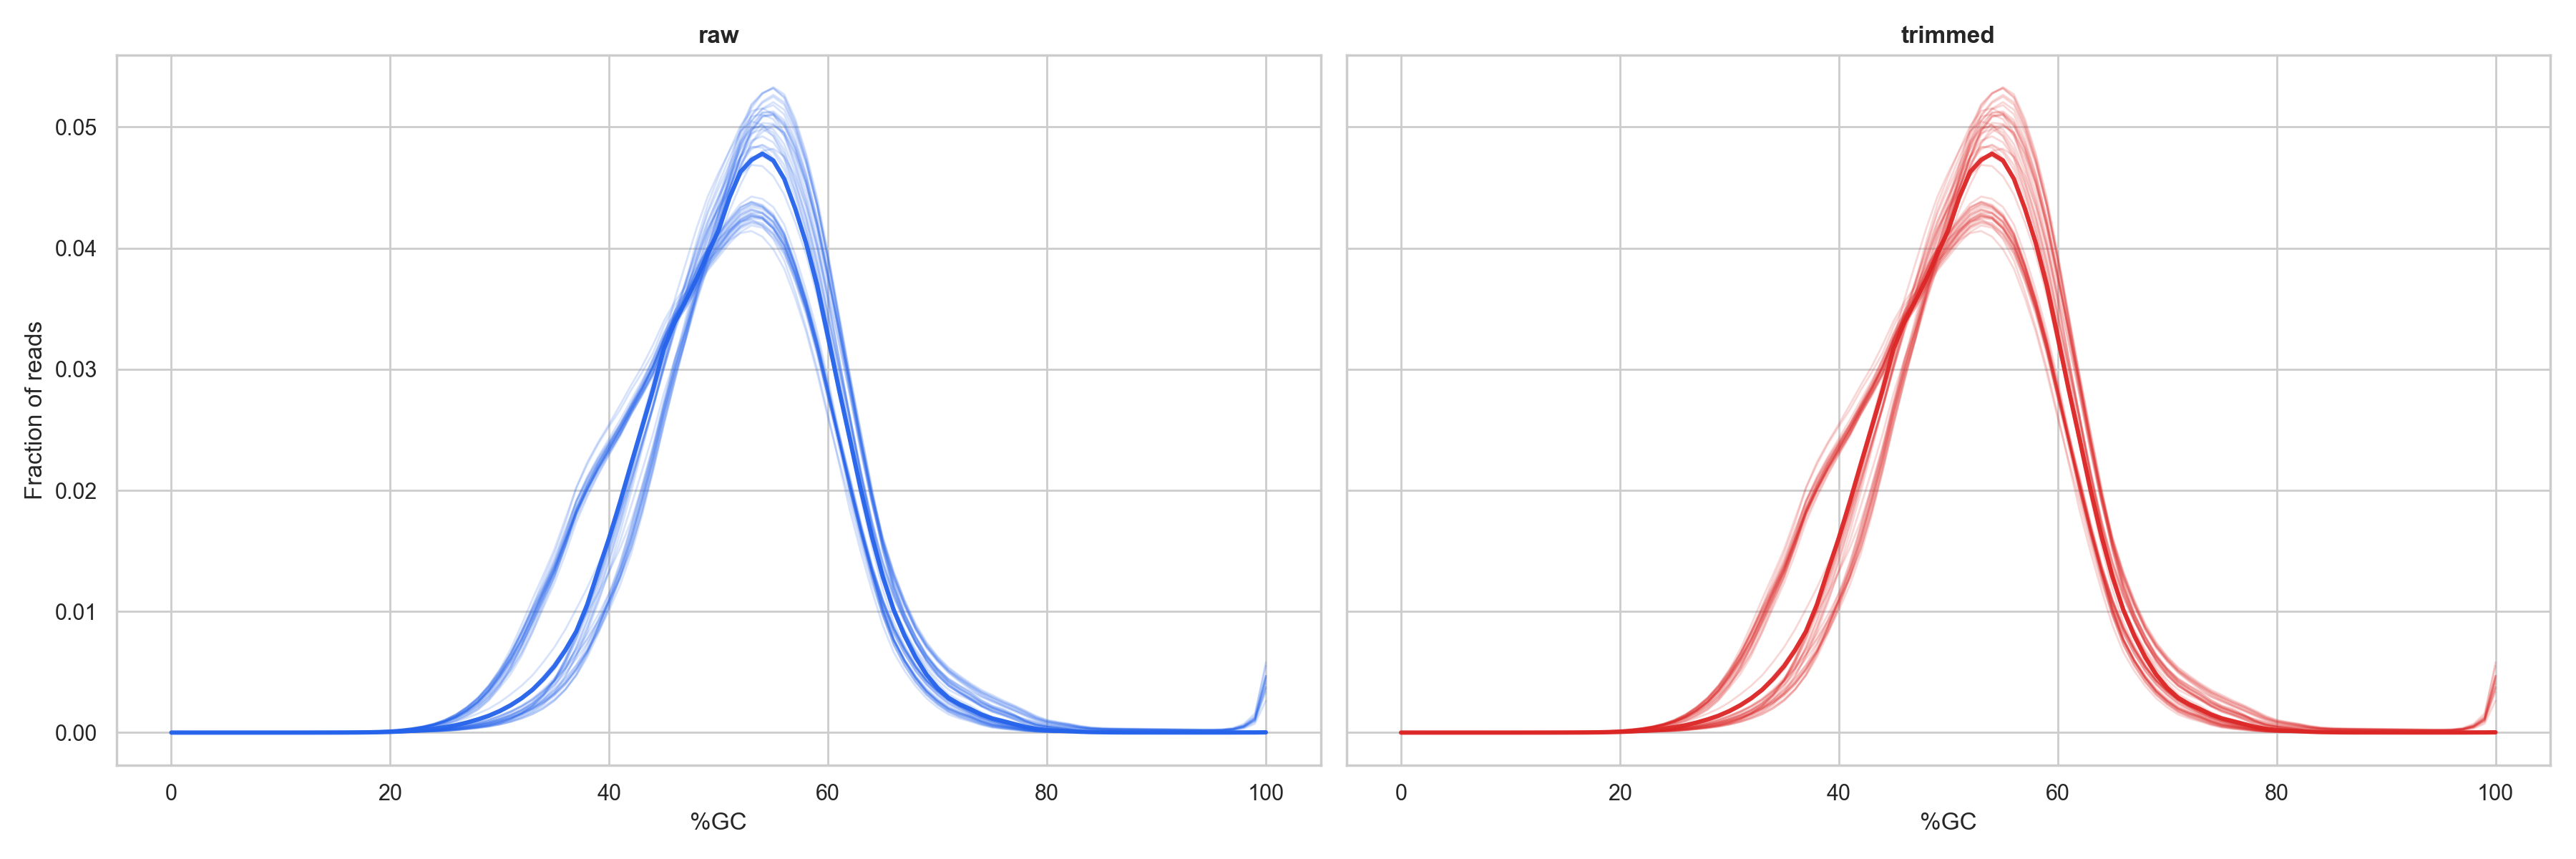

In [16]:
gc_bins = list(range(0, 101))
gc_matrix, gc_meta = build_matrix(
    zips,
    module_name='Per sequence GC content',
    x_col_guess=['GC Content', '%GC', 'GC'],
    y_col_guess=['Count'],
    x_bins=gc_bins
)

if gc_matrix is None:
    raise RuntimeError('No GC content tables found in the FastQC zips')

peaks = summarize_peaks(gc_matrix, gc_bins)
median_peak = int(np.median(peaks))
outliers = int((np.abs(peaks - median_peak) >= 10).sum())

findings = [
    f'Total reports parsed: {gc_matrix.shape[0]}',
    f'GC peak (median across reports): {median_peak}%',
    f'Outliers with peak shifted ≥10%GC from median: {outliers}',
    'Interpretation: broad or multi-peak GC can reflect mixed transcript populations or contamination; strong shifts in a subset are the red flags.',
]

gc_out = out_dir / 'fastqc_per_sequence_gc_content_all.png'
save_composite('Per sequence GC content', gc_matrix, gc_meta, gc_bins, gc_out, x_label='%GC')
gc_out
from pathlib import Path as _Path
display(Image(filename=str(_Path(out_dir) / 'fastqc_per_sequence_gc_content_all.png')))


### Notes — per-sequence GC content

- Raw vs trimmed curves are expected to be similar because trimming changes tail quality, not biological composition.
- The signal we care about is a subset of runs with a shifted peak or a second mode (possible contamination or markedly different composition); the figure’s outlier count summarizes that risk.

**Next:** any GC-peak outliers should be cross-checked against Overrepresented Sequences and adapter metrics to separate contamination/library artifacts from normal RNA-seq composition effects.



### 7A2. Sequence length distribution

*Subtitle:* Explains why “Sequence Length Distribution” often flips to WARN after trimming (variable read lengths).


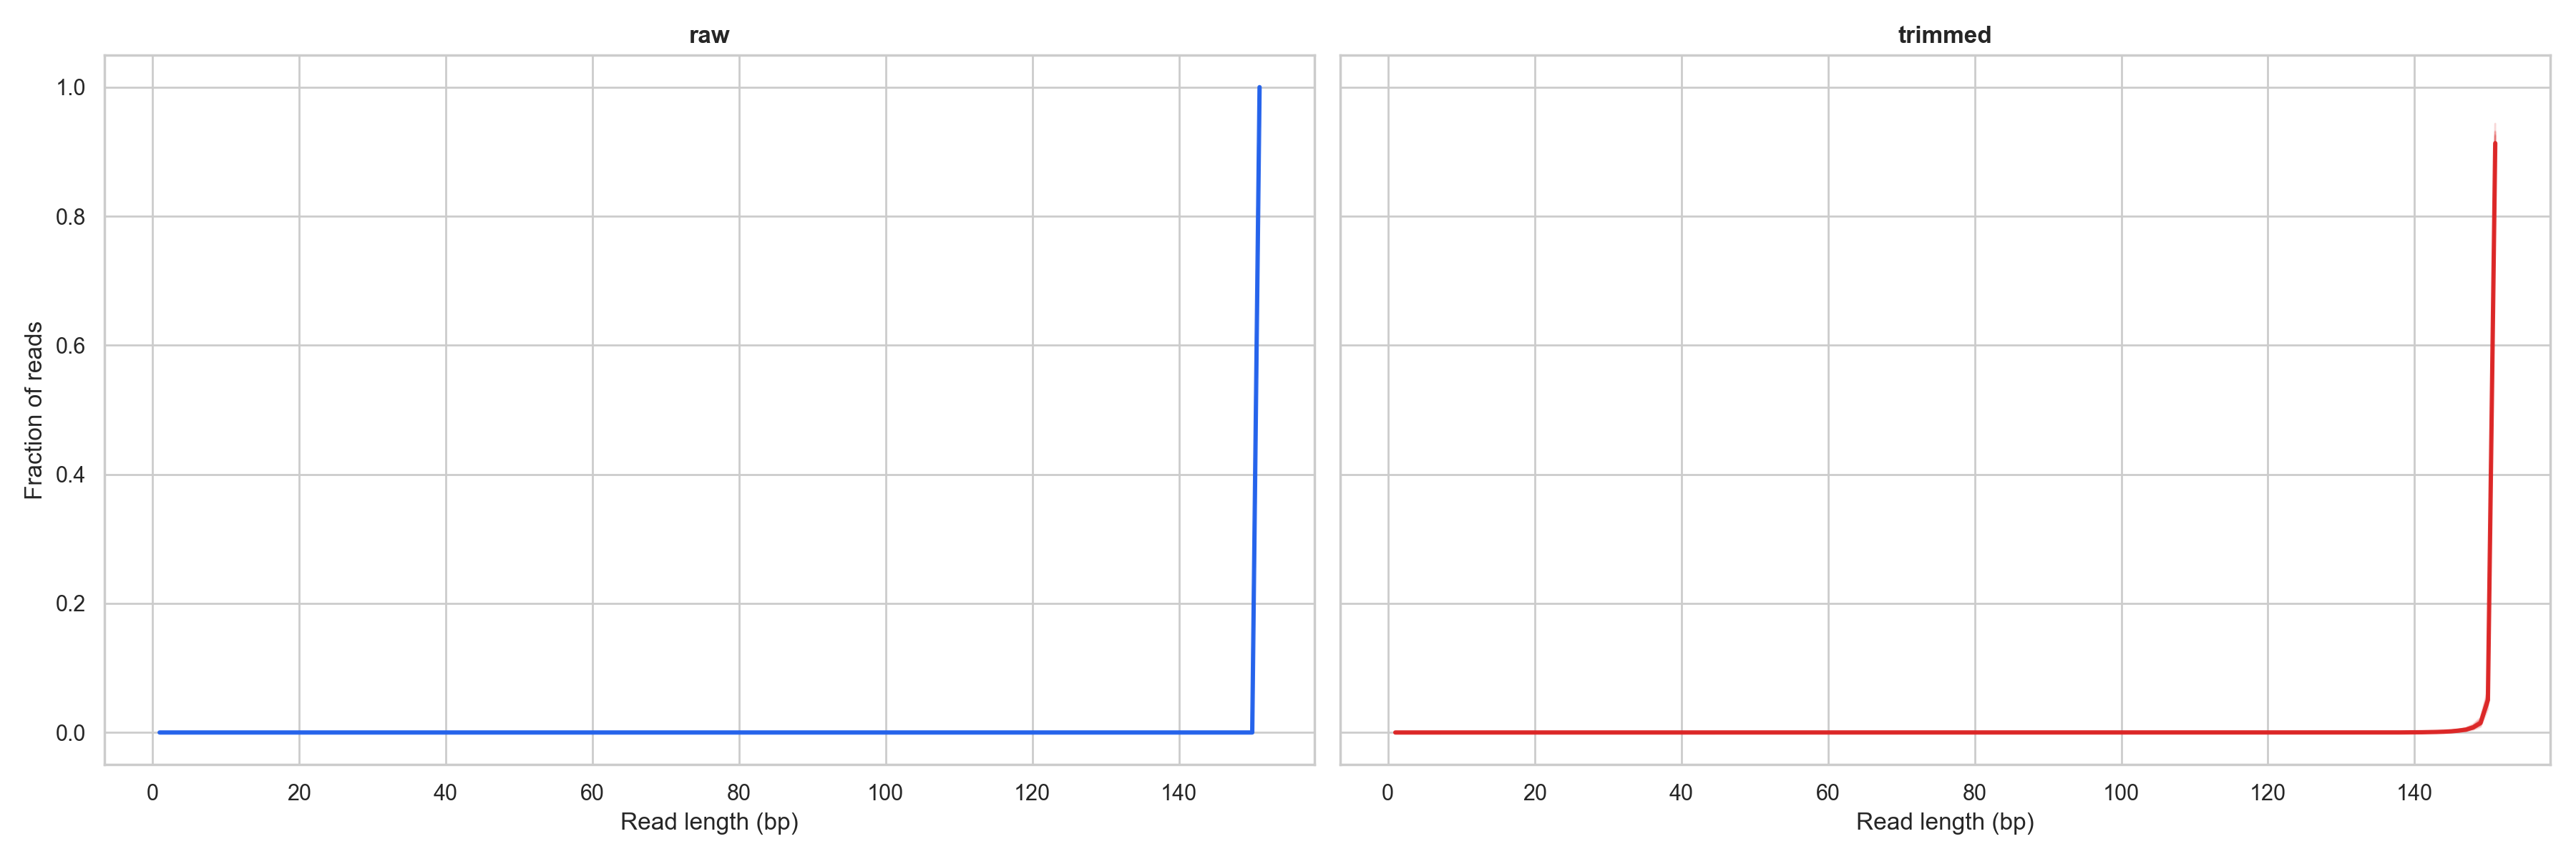

In [17]:
length_tables = []
for zp in zips:
    df = read_module_table_from_zip(zp, 'Sequence Length Distribution')
    if df is None:
        continue
    length_tables.append(df)

if not length_tables:
    raise RuntimeError('No Sequence Length Distribution tables found')

len_df = pd.concat(length_tables, ignore_index=True)
x_col = next((c for c in ['Length', 'Sequence Length'] if c in len_df.columns), None)
y_col = next((c for c in ['Count'] if c in len_df.columns), None)
if not x_col or not y_col:
    raise RuntimeError(f'Unexpected columns in length distribution: {list(len_df.columns)}')

len_df[x_col] = pd.to_numeric(len_df[x_col], errors='coerce')
len_df[y_col] = pd.to_numeric(len_df[y_col], errors='coerce')
max_len = int(np.nanmax(len_df[x_col].values))
length_bins = list(range(1, max_len + 1))

len_matrix, len_meta = build_matrix(
    zips,
    module_name='Sequence Length Distribution',
    x_col_guess=[x_col],
    y_col_guess=[y_col],
    x_bins=length_bins
)

peaks = summarize_peaks(len_matrix, length_bins)
median_len = int(np.median(peaks))
variable = int((len_matrix.max(axis=1) < 0.95).sum())

findings = [
    f'Total reports parsed: {len_matrix.shape[0]}',
    f'Modal read length (median across reports): {median_len}',
    f'Reports not dominated by a single length bin (<95% in one bin): {variable}',
    'Interpretation: fixed-length is expected pre-trim; variable-length is expected post-trim. A few variable-length raw reports can indicate prior trimming or nonstandard processing.',
]

len_out = out_dir / 'fastqc_sequence_length_distribution_all.png'
save_composite('Sequence Length Distribution', len_matrix, len_meta, length_bins, len_out, x_label='Read length (bp)')
len_out
from pathlib import Path as _Path
display(Image(filename=str(_Path(out_dir) / 'fastqc_sequence_length_distribution_all.png')))


### Notes — sequence length distribution

- Fixed-length raw reads typically appear as a single dominant spike; trimming broadens the distribution by shortening some reads.
- This explains why **Sequence Length Distribution** often flips to WARN after trimming: variable length is an expected side-effect, not automatically a quality failure.
- Highly variable raw lengths would suggest prior trimming or mixed preprocessing upstream.

**Next:** confirm trimming parameters (quality threshold + minimum length) and verify we are not over-trimming into overly short reads.



### 7A3. Sequence duplication levels

*Subtitle:* Duplication is often high in RNA-seq due to highly expressed transcripts; we mainly watch for extreme low-complexity outliers.


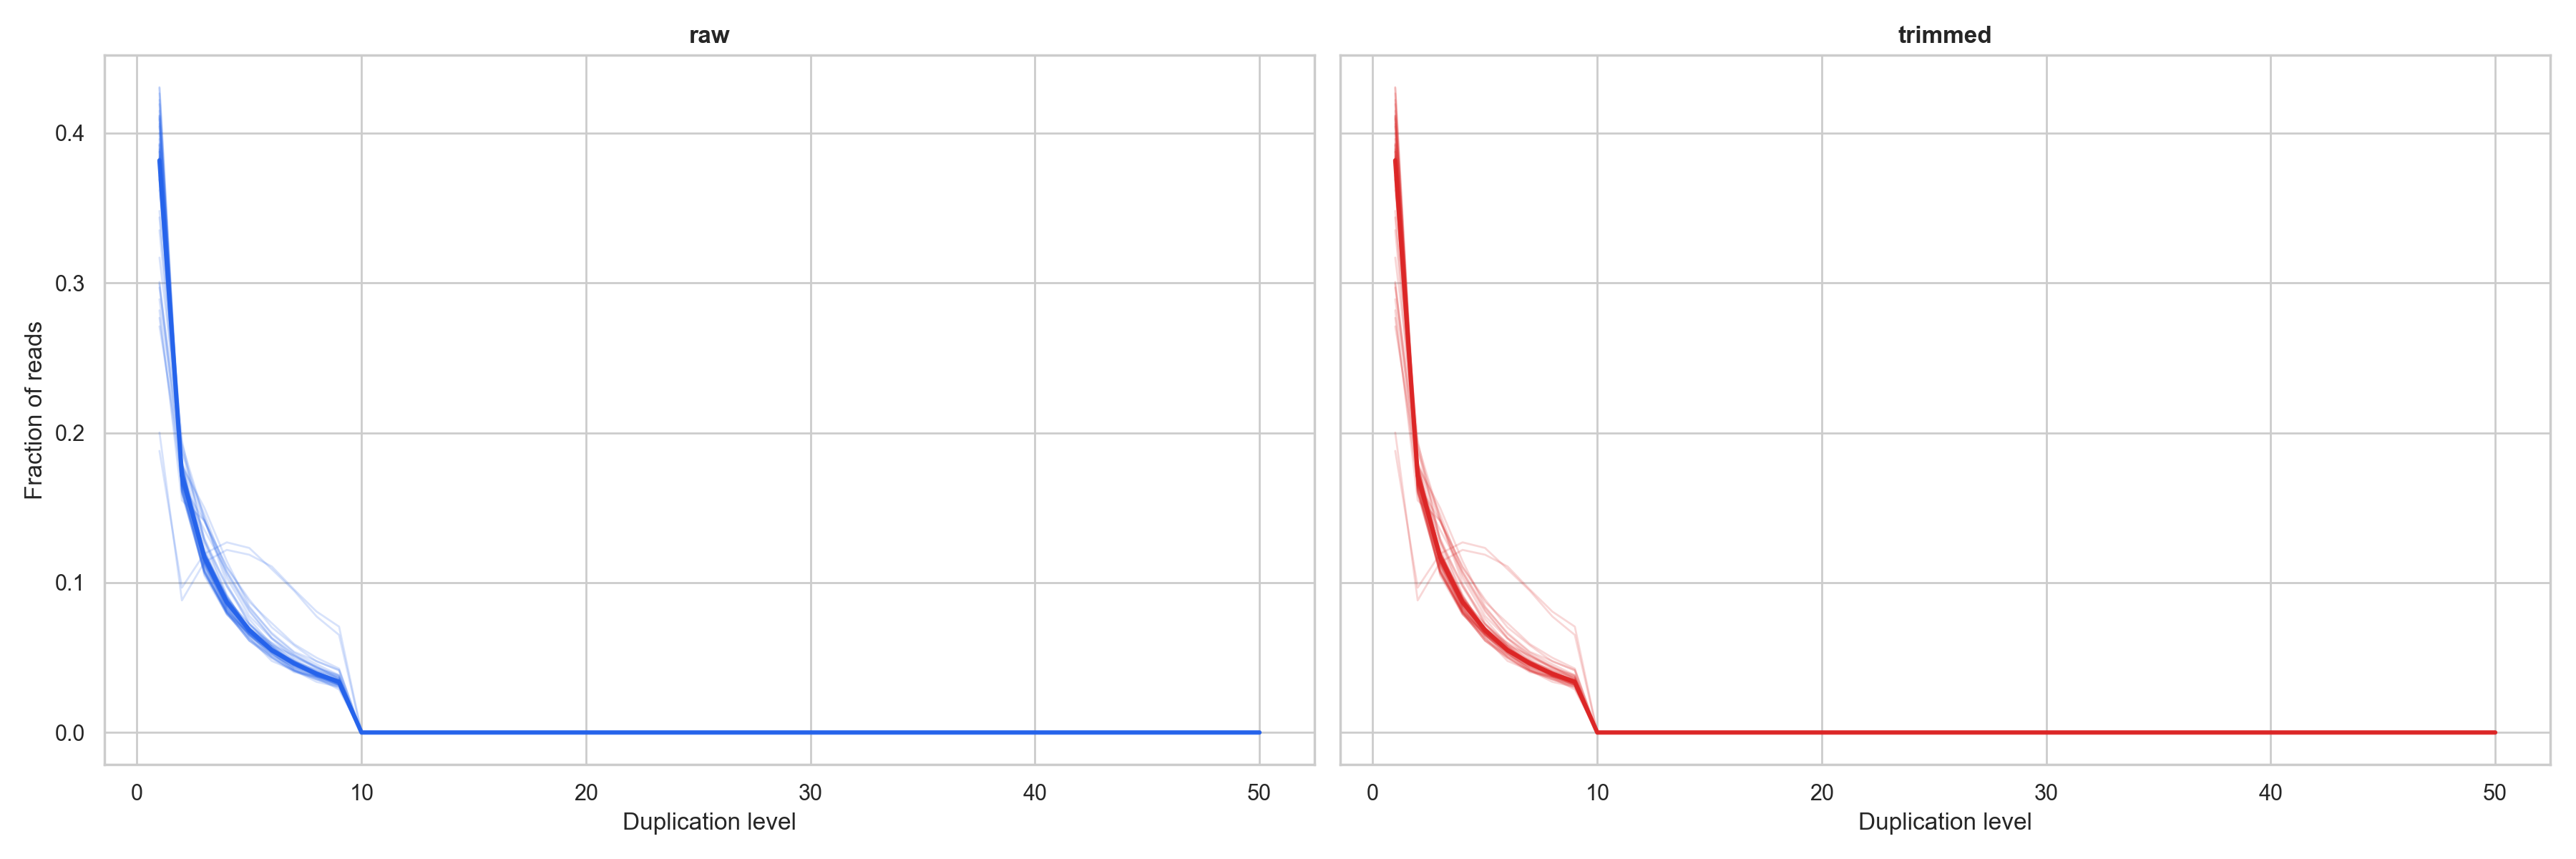

In [18]:
dup_bins = list(range(1, 51))
dup_matrix, dup_meta = build_matrix(
    zips,
    module_name='Sequence Duplication Levels',
    x_col_guess=['Duplication Level'],
    y_col_guess=['Percentage of total'],
    x_bins=dup_bins
)

if dup_matrix is None:
    raise RuntimeError('No duplication tables found')

unique_frac = dup_matrix[:, 0]
median_unique = float(np.median(unique_frac))
low_unique = int((unique_frac < 0.2).sum())

findings = [
    f'Total reports parsed: {dup_matrix.shape[0]}',
    f'Unique fraction (duplication level 1) median: {median_unique:.2f}',
    f'Reports with unique fraction < 0.20: {low_unique}',
    'Interpretation: RNA-seq often shows duplication due to highly expressed transcripts; still, unusually extreme duplication in a subset can flag low complexity or PCR artifacts.',
]

dup_out = out_dir / 'fastqc_sequence_duplication_levels_all.png'
save_composite('Sequence Duplication Levels', dup_matrix, dup_meta, dup_bins, dup_out, x_label='Duplication level')
dup_out
from pathlib import Path as _Path
display(Image(filename=str(_Path(out_dir) / 'fastqc_sequence_duplication_levels_all.png')))


### Notes — sequence duplication levels

- RNA-seq often shows substantial duplication due to highly expressed transcripts; trimming usually does not change this pattern.
- The main value here is outlier detection: unusually low unique fraction across a subset can flag low complexity or PCR artifacts.

**Next:** document duplication as expected context unless extreme outliers appear; prioritize adapter cleanup + tail-quality outliers for pipeline changes.



After reporting the cells above, you will have three composite images saved to `qc_bundle/qc_analysis_raw_vs_trimmed/` and displayed in the notebook.

Use them to answer the team questions:

- Do the GC curves cluster tightly (expected) or split into distinct shapes/peaks (possible mixed populations/contamination)?
- Are read lengths fixed (raw) and variable (trimmed) in the expected way?
- Is duplication uniformly high across samples (common for RNA-seq) or are there clear outliers that may need special handling?
